In [1]:
import xarray as xr
import numpy as np
import gsw
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import ffmpeg
import pylab as pl
import pandas as pd
from math import radians, cos
from matplotlib.gridspec import GridSpec

In [56]:
project='highRes'
ed='run7/'

directory='/Users/ameliaking/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

var='dynDiag'

ds=xr.open_dataset(str(location) +  str(var) + '.nc')


varS='surfDiag'

dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')


#Take them minus 1 and 2 to skip the boundary
ny=len(ds.Y)
nx=len(ds.X) 
nz=len(ds.diag_levels)
nt=len(ds.T) 

umbral=ny*0.5

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

info=pd.read_csv(str(dataloc) + 'data',sep='/n')
parameters=['viscAh','viscAr','diffKhT','diffKrT']


if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
else:
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1

/var/folders/gd/3bct0xc153g57jtc04sdbb240000gn/T/ipykernel_35676/2178989725.py:47: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  info=pd.read_csv(str(dataloc) + 'data',sep='/n')


In [57]:
plotNames=['Horizontal viscosity','Vertical viscosity','Horizontal diffusivity','Vertical diffusivity']
plotValues=[]
for name in parameters:
    var=np.where(info['# Model parameters'].str.contains(name).values)[0][0]
    whereEnd=info.loc[var].str.find(',').values[0]
    where=1+info.loc[var].str.find('=').values[0]
    plotValues.append(info.loc[var].str[where:whereEnd].values[0])
    

In [58]:
def animate(t):
    tt=((ds.T.values[t])/(60*60*24*360))
    cax0.set_array(np.ma.masked_array(T[t,:,OBp:OBendp,0],mask=mask[:,OBp:OBendp,0]))
    cax1.set_array(np.ma.masked_array(V[t,:,OBp:OBendp,0]*100,mask=masks[:,OBp:OBendp,0]))
    cax2.set_array(np.ma.masked_array(np.mean(U[t,:,OBp:OBendp,:],axis=2)*100,mask=maskw[:,OBp:OBendp,0]))
    cax3.set_array(np.ma.masked_array(W[t,:,OBp:OBendp,0]*100,mask=mask[:,OBp:OBendp,0]))
    fig.suptitle(f'After {tt:.1f} years')



In [59]:
Writer = animation.writers['ffmpeg']
writer = Writer(fps=4, metadata=dict(artist='AM'), bitrate=2000)

In [60]:
tin=-10
divV=1
divU=1
divW=1

In [61]:
np.where(ds.T/(3600*24*360)>10)

(array([], dtype=int64),)

In [62]:
params = {'font.size': 10,
          'figure.figsize': (8, 4),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

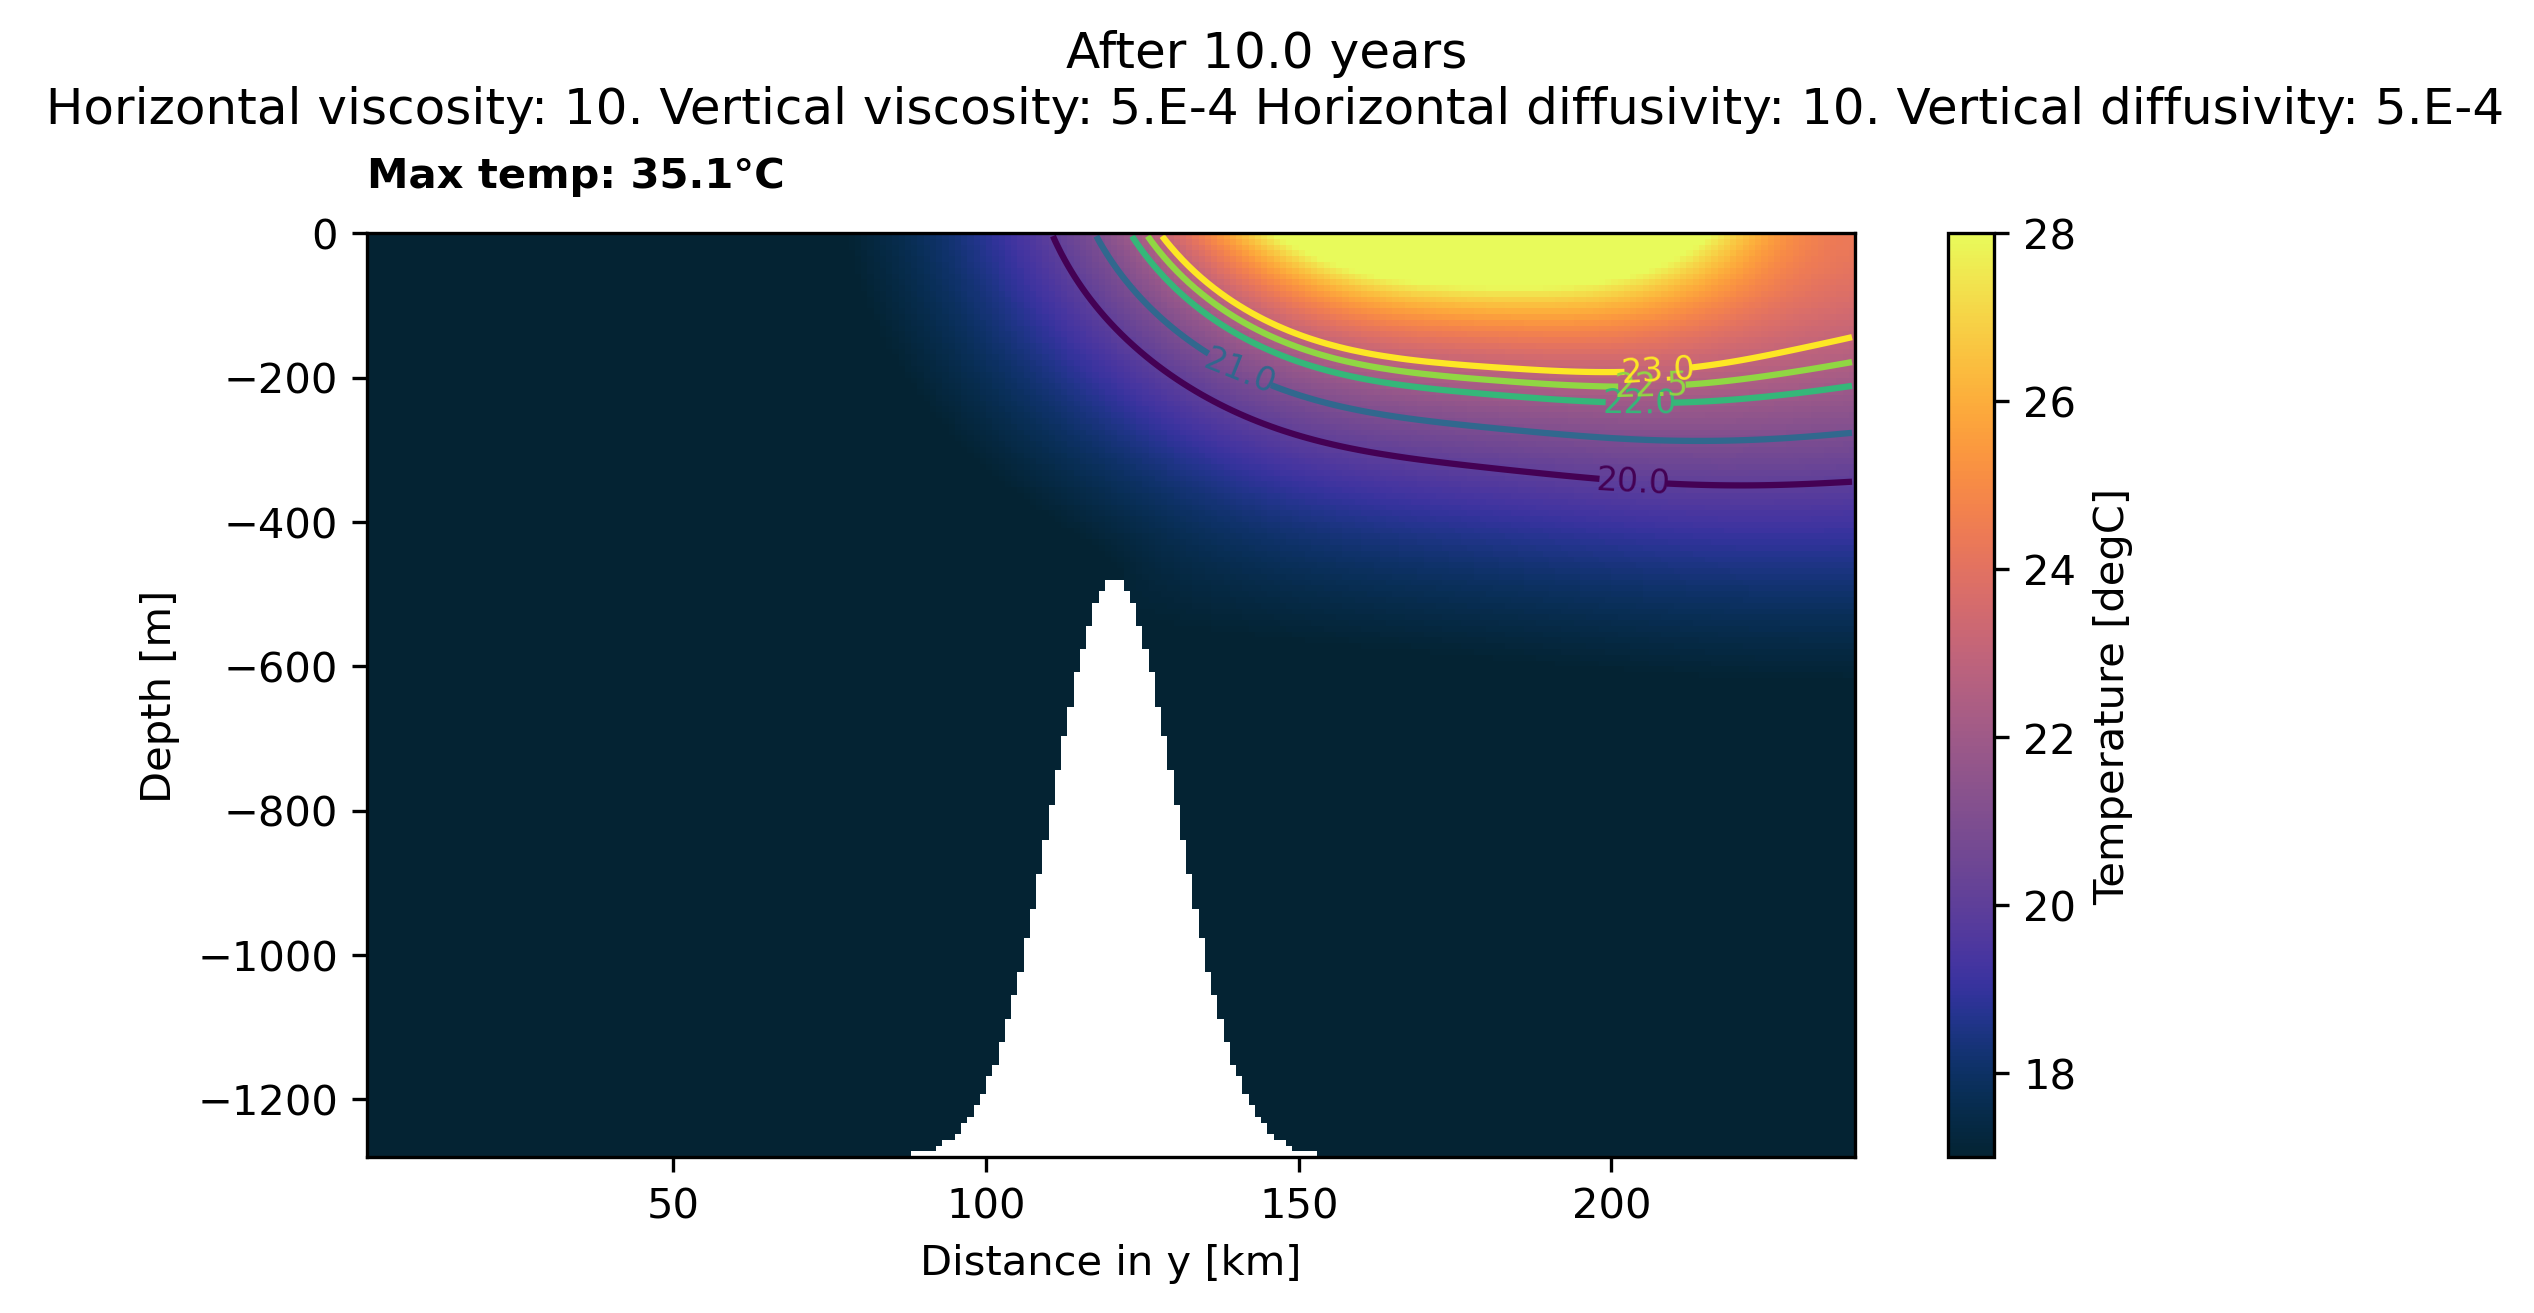

In [64]:
fig,axin = plt.subplots()
axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

T=ds.THETA
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Z

vmin=np.min(np.ma.masked_array(T[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))
vmax=np.max(np.ma.masked_array(T[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))
cmapi=cmocean.cm.thermal


timein=ds.T[19]/(60*60*24*360)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[19,:,OBp:OBendp,0],mask=mask[:,OBp:OBendp,0]),vmin=17,vmax=28,cmap=cmapi)
caxC=axin.contour(Yin/1000, Zin, np.ma.masked_array(T[19,:,OBp:OBendp,0]),levels=[20,21,22,22.5,23]) #levels=[16,16.5,16.8,17.2,18,20])
#Run 7 levels=[15,15.5,16,16.2,16.5,16.8,17.2,18,20])
#Run 6 levels=[20,21,22,22.5,23])
fig.suptitle(f'After {timein:.1f} years\n {plotNames[0]}: {plotValues[0]} {plotNames[1]}: {plotValues[1]} {plotNames[2]}: {plotValues[2]} {plotNames[3]}: {plotValues[3]}',y=1.05)

axin.text(0, 1.05, f'Max temp: {np.max(np.ma.masked_array(T[-1,:,OB:OBend,0],mask=mask[:,OB:OBend,0])):.1f}°C', fontweight='bold', color='k',
        transform=axin.transAxes)
plt.clabel(caxC, inline=1, fontsize=8)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Temperature [degC]')

Text(0.5, 1.05, 'After 10.0 years\n Horizontal viscosity: 10. Vertical viscosity: 1.E-3 Horizontal diffusivity: 10. Vertical diffusivity: 1.E-3')

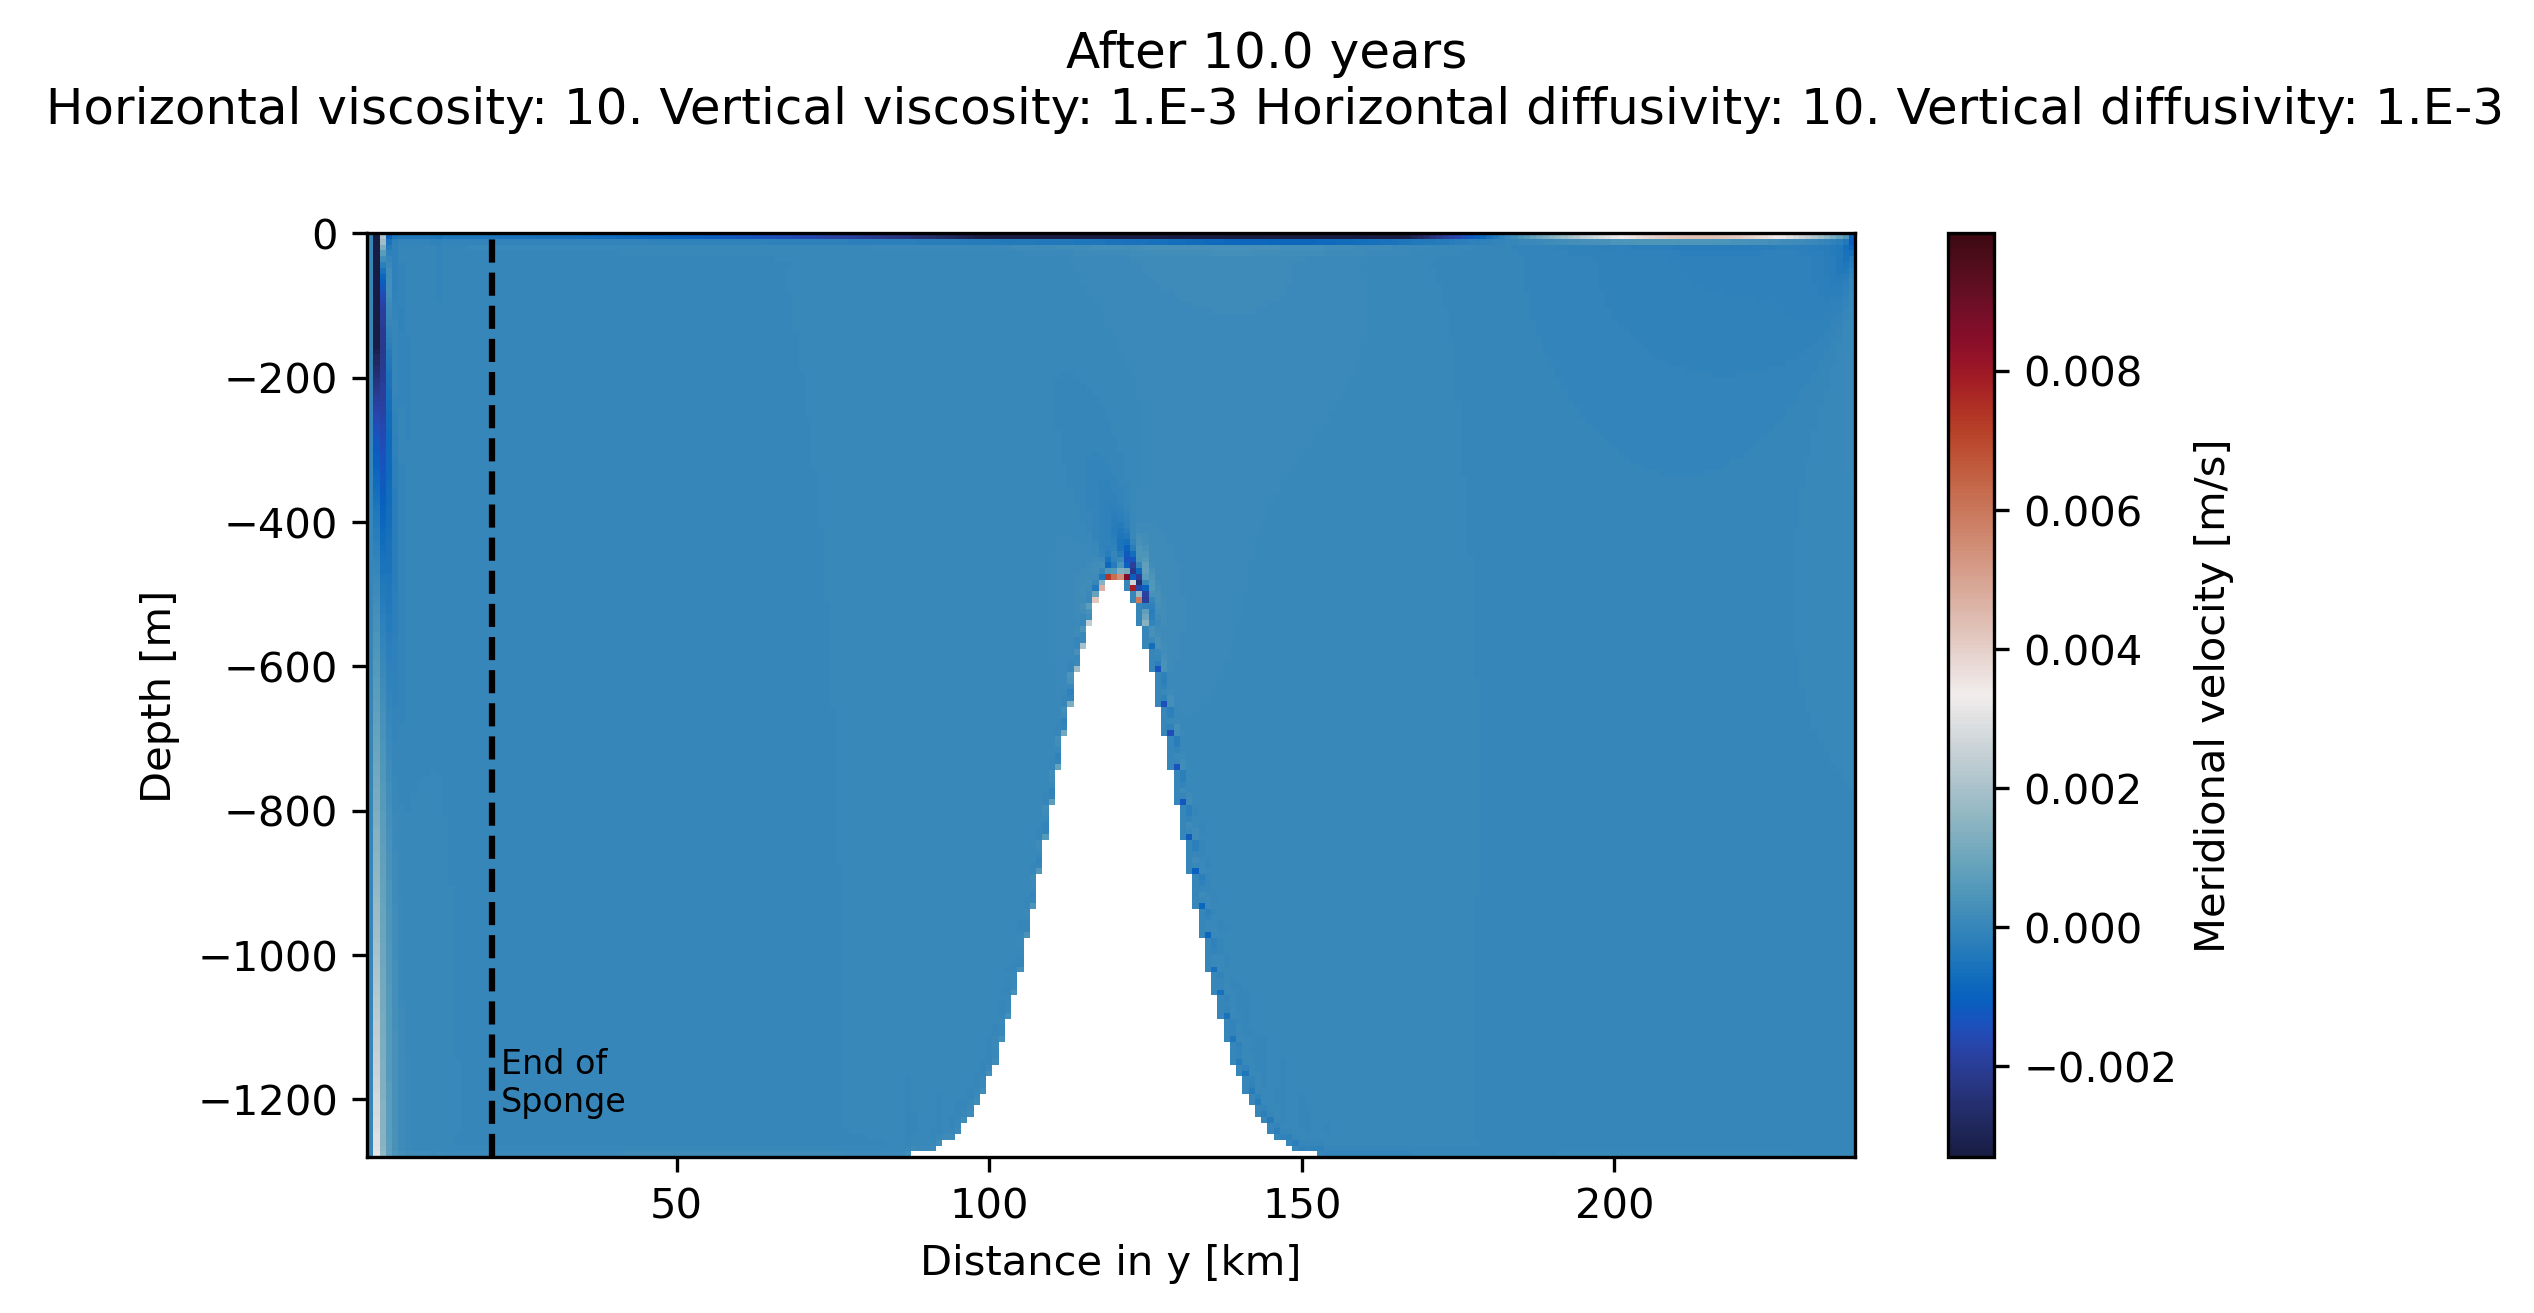

In [55]:
fig,axin = plt.subplots()
axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

V=ds.VVEL[:,:,:-1,:]
Yin=dsG.Yp1[OBp:OBendp-1]
Zin=dsG.Z

vmin=np.min(np.ma.masked_array(V[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))/10
vmax=np.max(np.ma.masked_array(V[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))/10
cmapi=cmocean.cm.balance


timein=ds.T[20]/(60*60*24*360)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(V[20,:,OBp:OBendp,0],mask=mask[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, np.ma.masked_array(V[-1,:,OBp:OBendp,0]),levels=0)#[15,15.5,16,16.2,16.5,16.8,17.2,18,20])
#plt.clabel(caxC, inline=1, fontsize=8)
axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Meridional velocity [m/s]')
fig.suptitle(f'After {timein:.1f} years\n {plotNames[0]}: {plotValues[0]} {plotNames[1]}: {plotValues[1]} {plotNames[2]}: {plotValues[2]} {plotNames[3]}: {plotValues[3]}',y=1.05)


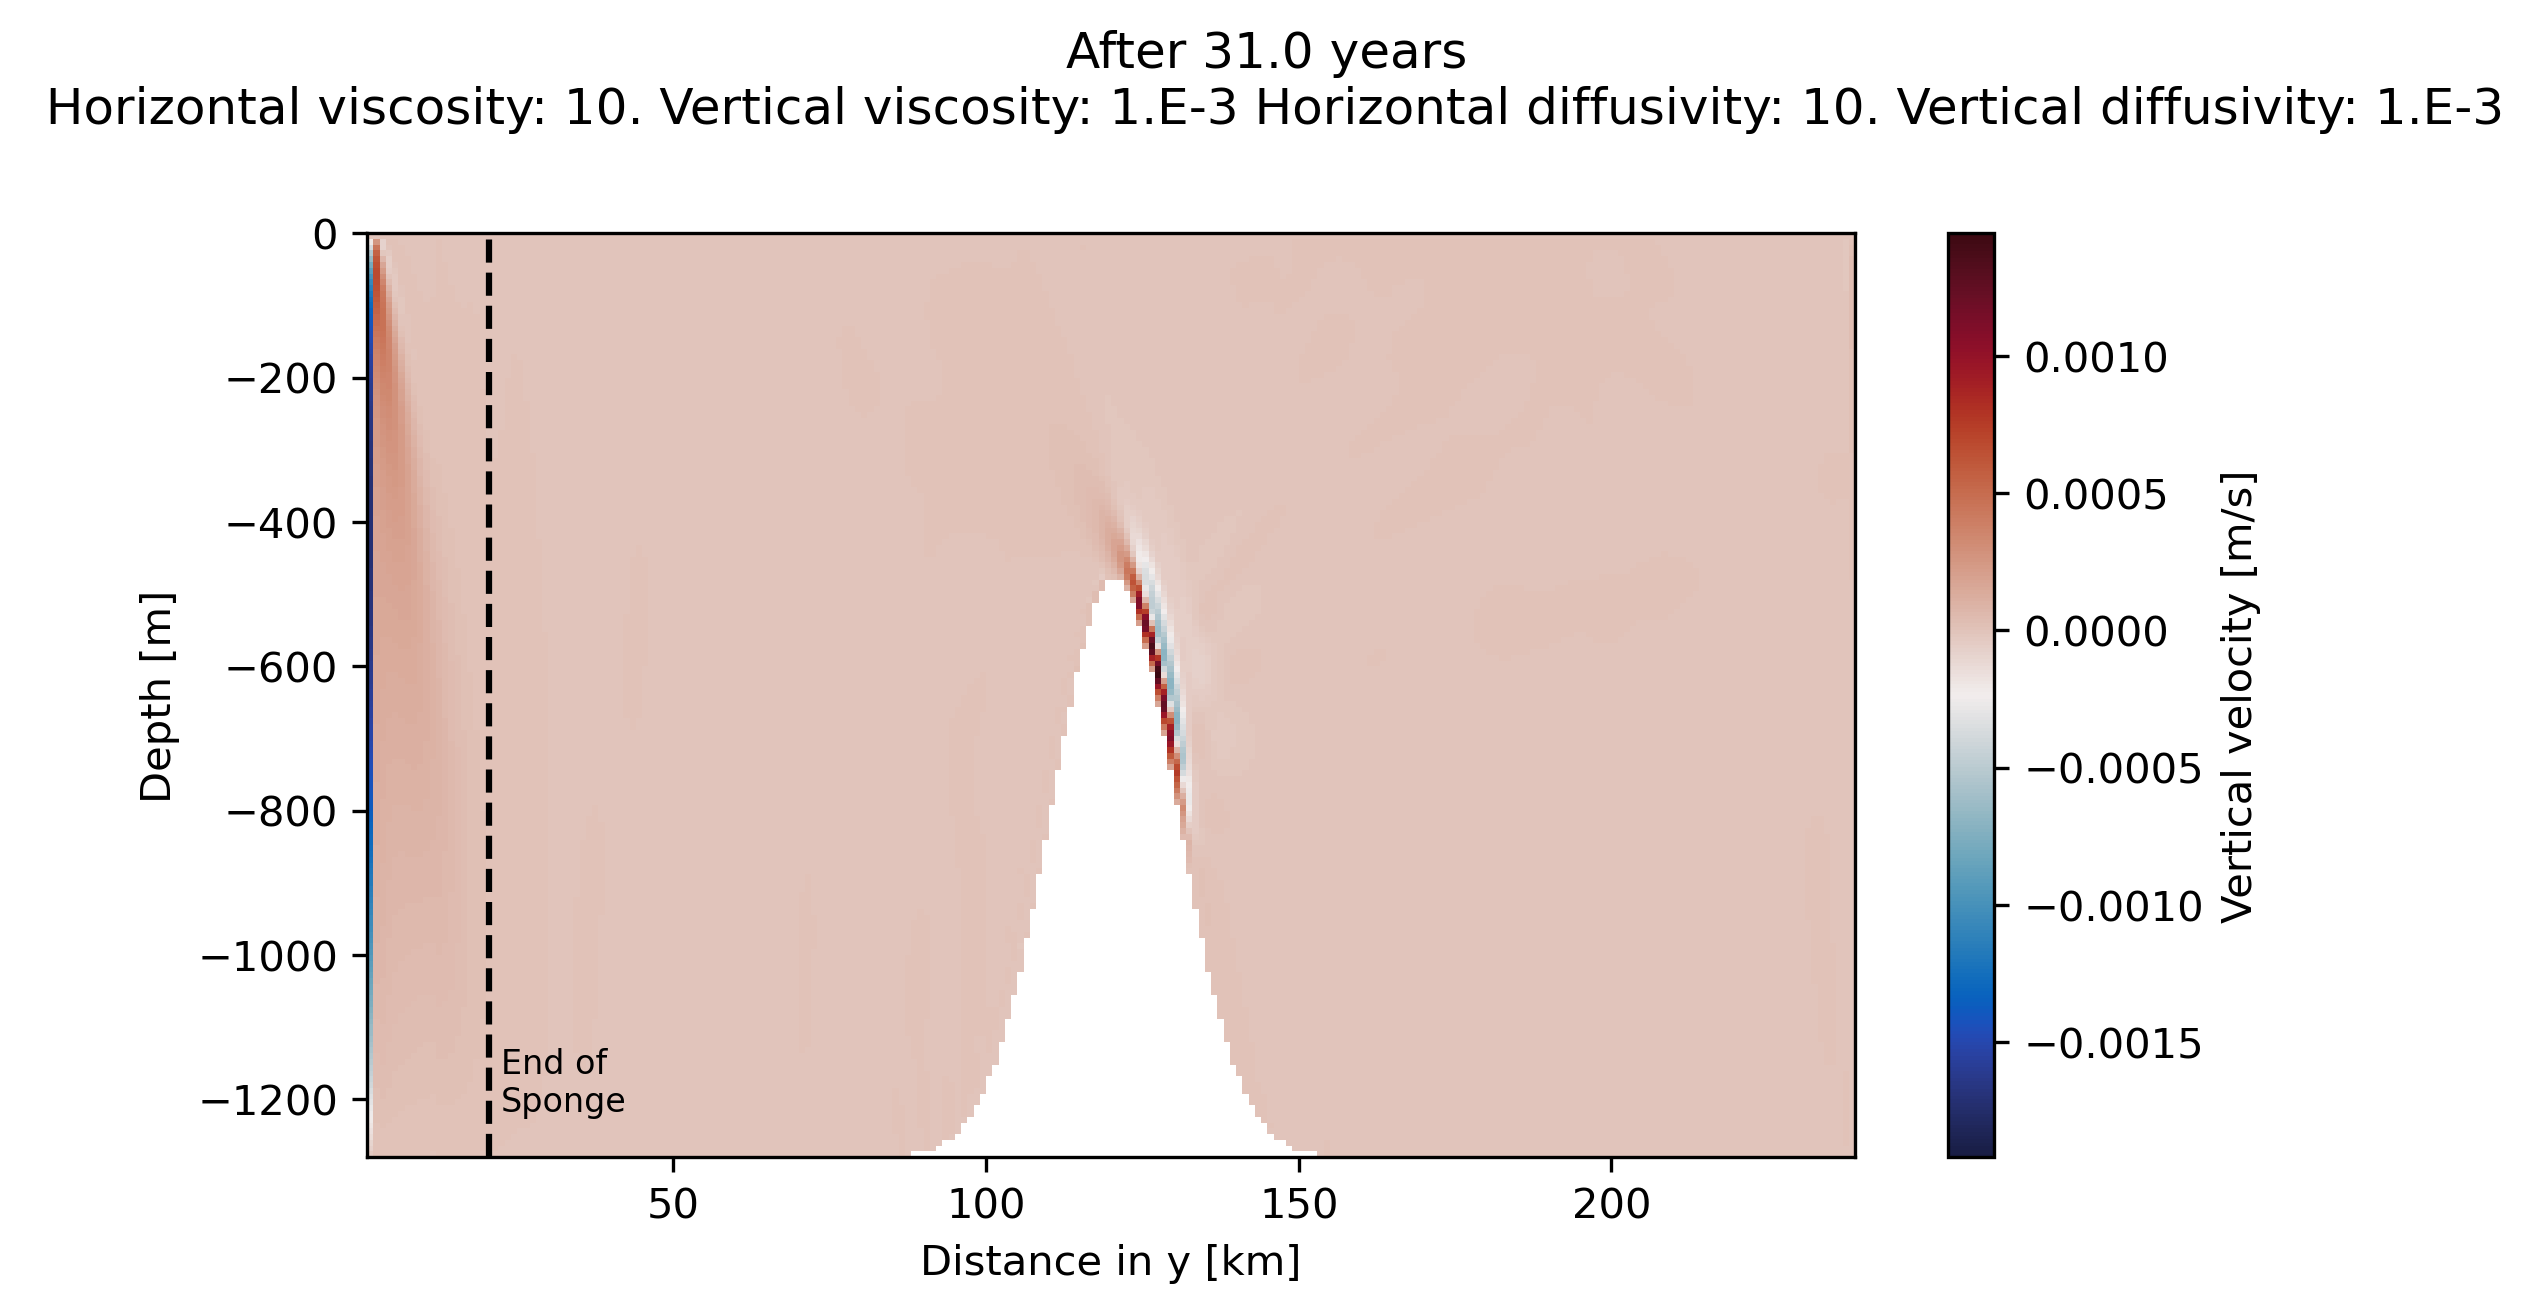

In [47]:
fig,axin = plt.subplots()
axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

W=ds.WVEL
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Z

vmin=np.min(np.ma.masked_array(W[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))
vmax=np.max(np.ma.masked_array(W[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))
cmapi=cmocean.cm.balance


timein=ds.T[-1]/(60*60*24*360)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(W[-1,:,OBp:OBendp,0],mask=mask[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, np.ma.masked_array(W[-1,:,OBp:OBendp,0]),levels=0)#[15,15.5,16,16.2,16.5,16.8,17.2,18,20])
fig.suptitle(f'After {timein:.1f} years\n {plotNames[0]}: {plotValues[0]} {plotNames[1]}: {plotValues[1]} {plotNames[2]}: {plotValues[2]} {plotNames[3]}: {plotValues[3]}',y=1.05)

axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Vertical velocity [m/s]')

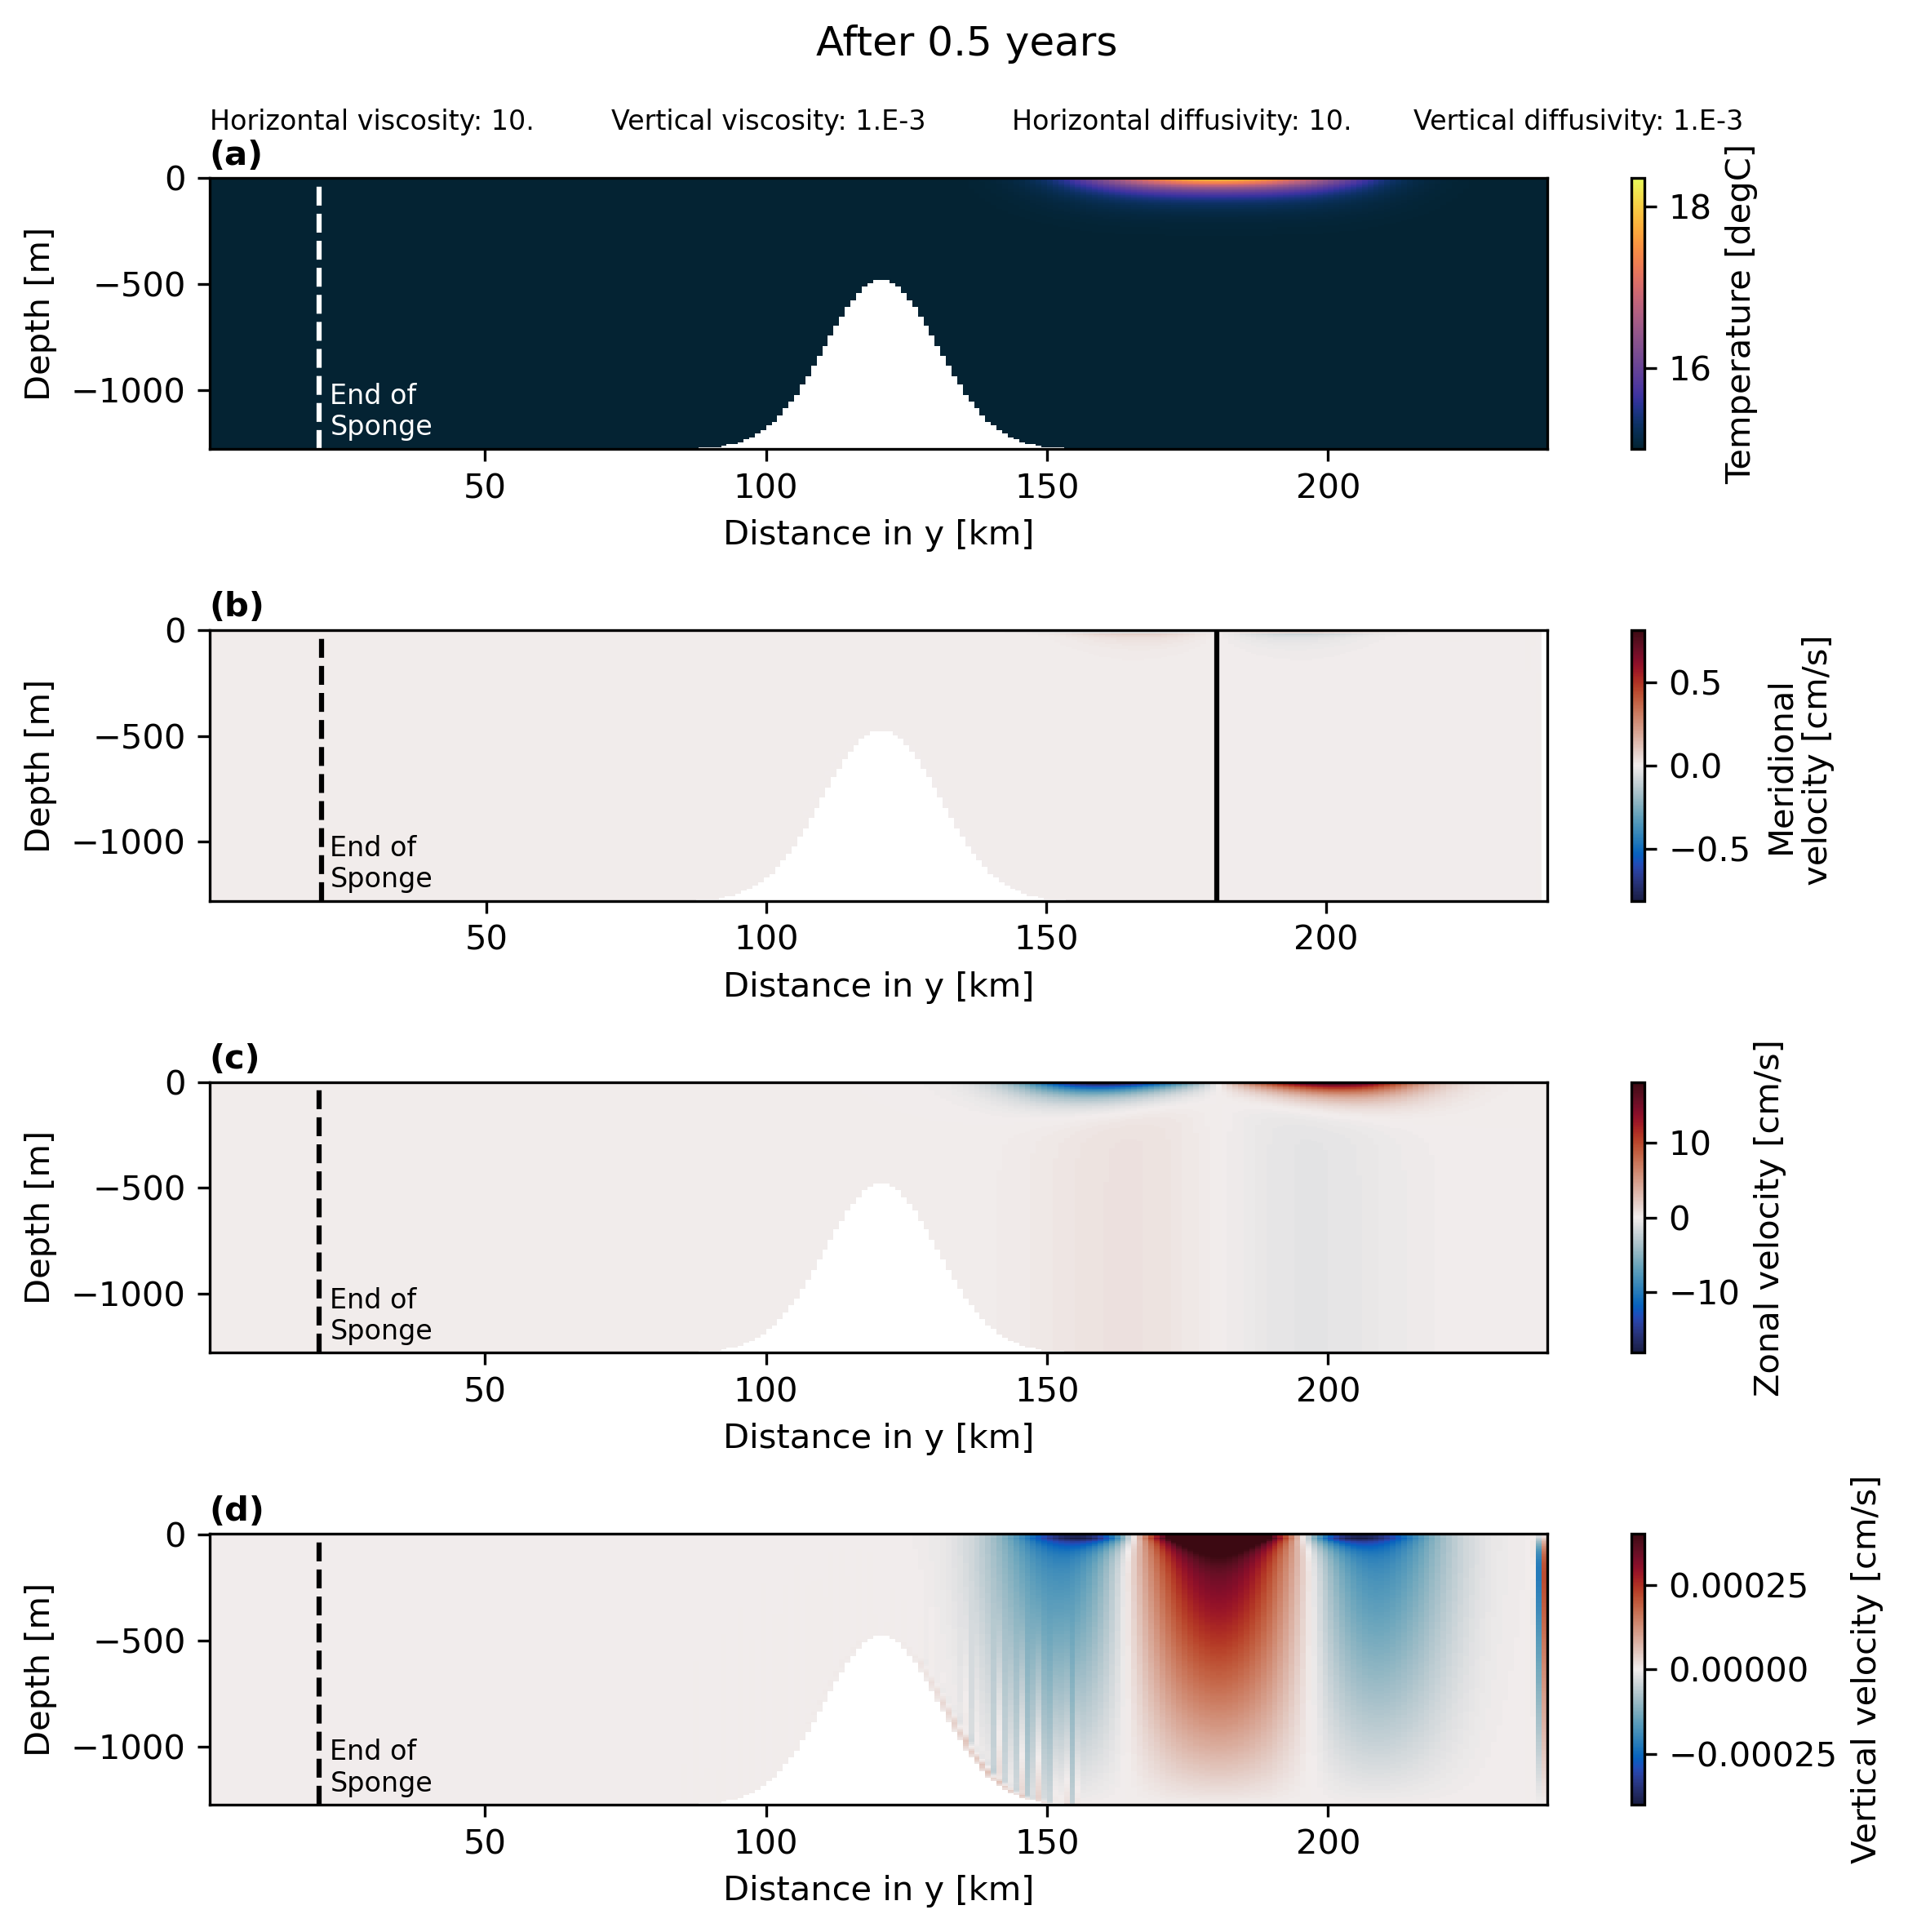

In [66]:
params = {'font.size': 10,
          'figure.figsize': (8, 8),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
tin=0
fig = plt.figure()
gs = GridSpec(nrows=4, ncols=1)
axin = fig.add_subplot(gs[0, 0])
axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

T=ds.THETA
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Z

vmin=np.min(np.ma.masked_array(T[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))
vmax=np.max(np.ma.masked_array(T[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))
cmapi=cmocean.cm.thermal


timein=ds.T[tin]/(60*60*24*360)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp,0],mask=mask[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp,0]),levels=[15,15.02,15.08,15.2,15.5],colors='cyan')
#plt.clabel(caxC, inline=1, fontsize=8)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Temperature [degC]')

axin.text(0, 1.05, '(a)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[20]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

s=1.18
for i in range(len(plotNames)):
    if i>3:
        s=1.15
        i=i-2
    axin.text(0+i*0.3, s, f'{plotNames[i]}: {plotValues[i]}', color='black', 
            transform=axin.transAxes,fontsize=8)

    
#axin.set_title(f'{plotNames[0]}:{plotValues[0]}, {plotNames[1]}:{plotValues[1]}\n {plotNames[2]}:{plotValues[2]}, {plotNames[3]}:{plotValues[3]}',fontsize=10)


axin = fig.add_subplot(gs[1, 0])

V=ds.VVEL.values

title= ds.VVEL.description 
Yin=ds.Yp1[OBp:OBendp]

vmin=np.min(np.ma.masked_array(V[tin,:,OB:OBend,0]*100,mask=masks[:,OB:OBend,0]))/divV
vmax=-np.min(np.ma.masked_array(V[tin,:,OB:OBend,0]*100,mask=masks[:,OB:OBend,0]))/divV
cmapi=cmocean.cm.balance


axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax1=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(V[tin,:,OBp:OBendp,0]*100,mask=masks[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax1)
axin.axvline(ds.Y[int(0.75*ny)]/1000,c='k')
cbar_ax.set_label('Meridional\n velocity [cm/s]')




axin.text(0, 1.05, '(b)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[2, 0])

U=ds.UVEL
title= U.description 
Yin=ds.Y[OBp:OBendp]

vmin=np.min(np.ma.masked_array(np.mean(U[tin,:,OB:OBend,:],axis=2))*100)/divU
vmax=-np.min(np.ma.masked_array(np.mean(U[tin,:,OB:OBend,:],axis=2))*100)/divU
cmapi=cmocean.cm.balance



axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax2=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(np.mean(U[tin,:,OBp:OBendp,:],axis=2)*100,mask=maskw[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax2)
cbar_ax.set_label('Zonal velocity [cm/s]')


axin.text(0, 1.05, '(c)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)



W=ds.WVEL.values

title= ds.WVEL.description 
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Zl

vmin=np.min(np.ma.masked_array(W[tin,:,OB:OBend,0]*100,mask=mask[:,OB:OBend,0]))/divW
vmax=-np.min(np.ma.masked_array(W[tin,:,OB:OBend,0]*100,mask=mask[:,OB:OBend,0]))/divW
cmapi=cmocean.cm.balance

axin = fig.add_subplot(gs[3, 0])

axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

timein=ds.T[-tin]/(60*60*24)
cax3=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(W[tin,:,OBp:OBendp,0]*100,mask=mask[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax3)
cbar_ax.set_label('Vertical velocity [cm/s]')

axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

axin.text(0, 1.05, '(d)', fontweight='bold', color='k', 
        transform=axin.transAxes)
tt=0
fig.suptitle(f'After {tt:.1f} years')

fig.tight_layout()
anim = FuncAnimation(fig, animate,frames=np.arange(0,len(ds.T.values),1), repeat=False,interval=600)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'crossects'  +'viscHor'+str(plotValues[0])+'viscVert'+str(plotValues[1])+'diffHor'+str(plotValues[2]) +'diffVert'+str(plotValues[3])+ '.mp4', writer=writer, dpi=600)


In [67]:
#Rho elegante
#Zdens=np.ma.masked_array(np.tile(dsG.Z.values,(len(ds.THETA[0,0,1,:].values),len(ds.THETA[0,0,:,0].values),len(ds.THETA[0,0,0,:].values))).T,mask=mask)
#lat=(22.92+31.70)/2
#P=gsw.conversions.p_from_z(Zdens, lat)
#SA=np.ma.masked_array(np.zeros(np.shape(ds.THETA[0].values)),mask=mask)


#RHO=np.zeros(np.shape(ds.THETA.values))
#for i in range(len(ds.T)):
#    CT=gsw.conversions.CT_from_pt(SA, np.ma.masked_array(ds.THETA[i].values,mask=mask))
#    RHO[i,:,:,:]=gsw.density.sigma0(SA, CT)

In [68]:
#Rho Linear EOS
alpha=2*1e-4
RHO=np.zeros(np.shape(ds.THETA.values))
for i in range(len(ds.T)):
    RHO[i,:,:,:]=-999.8*np.ma.masked_array(ds.THETA[i].values-15,mask=mask)*alpha

In [69]:
def BottomConc(vel, hfac, nz,nt, ny,loc):
    '''vel: Velocity field (nt,nz,ny)
       hfac: fraction of open cell at center (nz,ny)
       
       
       RETURNS:
       
       BotVel = velocity near bottom (nt,ny)'''
    
    BotVel = np.empty((nt,ny))
    BottomInd = np.argmax(hfac[::-1,:]>0.0,axis=0) # start looking for first no-land cell from the bottom up.
    BottomInd = (np.ones(np.shape(BottomInd))*nz - BottomInd)-loc # Get index of unreversed z axis
    
    for j in range(nt):
        for i in range(ny): 
            BotVel[j,i] = vel[j,int(BottomInd[i]),i] 
                
    
    return (BotVel,BottomInd)


In [70]:
velout1,BottomInd1=BottomConc(V[:,:,:,0],hFacS[:,:,0].values , nz, nt, ny+1,1)
velout2,BottomInd2=BottomConc(V[:,:,:,0],hFacS[:,:,0].values , nz, nt, ny+1,2)

Wvelout1,BottomInd=BottomConc(W[:,:,:,0],hFacC[:,:,0].values , nz, nt, ny,1)
Wvelout2,BottomInd=BottomConc(W[:,:,:,0],hFacC[:,:,0].values , nz, nt, ny,20)

Rhoout1,BottomInd=BottomConc(RHO[:,:,:,0],hFacC[:,:,0].values , nz, nt, ny,1)
Rhoout2,BottomInd=BottomConc(RHO[:,:,:,0],hFacC[:,:,0].values , nz, nt, ny,20)

In [71]:
params = {'font.size': 14,
          'figure.figsize': (12, 12),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [72]:
tin=np.where(ds.T/(24*60*60*360)>9)[0][0]
tinplot=np.where(ds.T/(24*60*60*360)>0)[0][0]

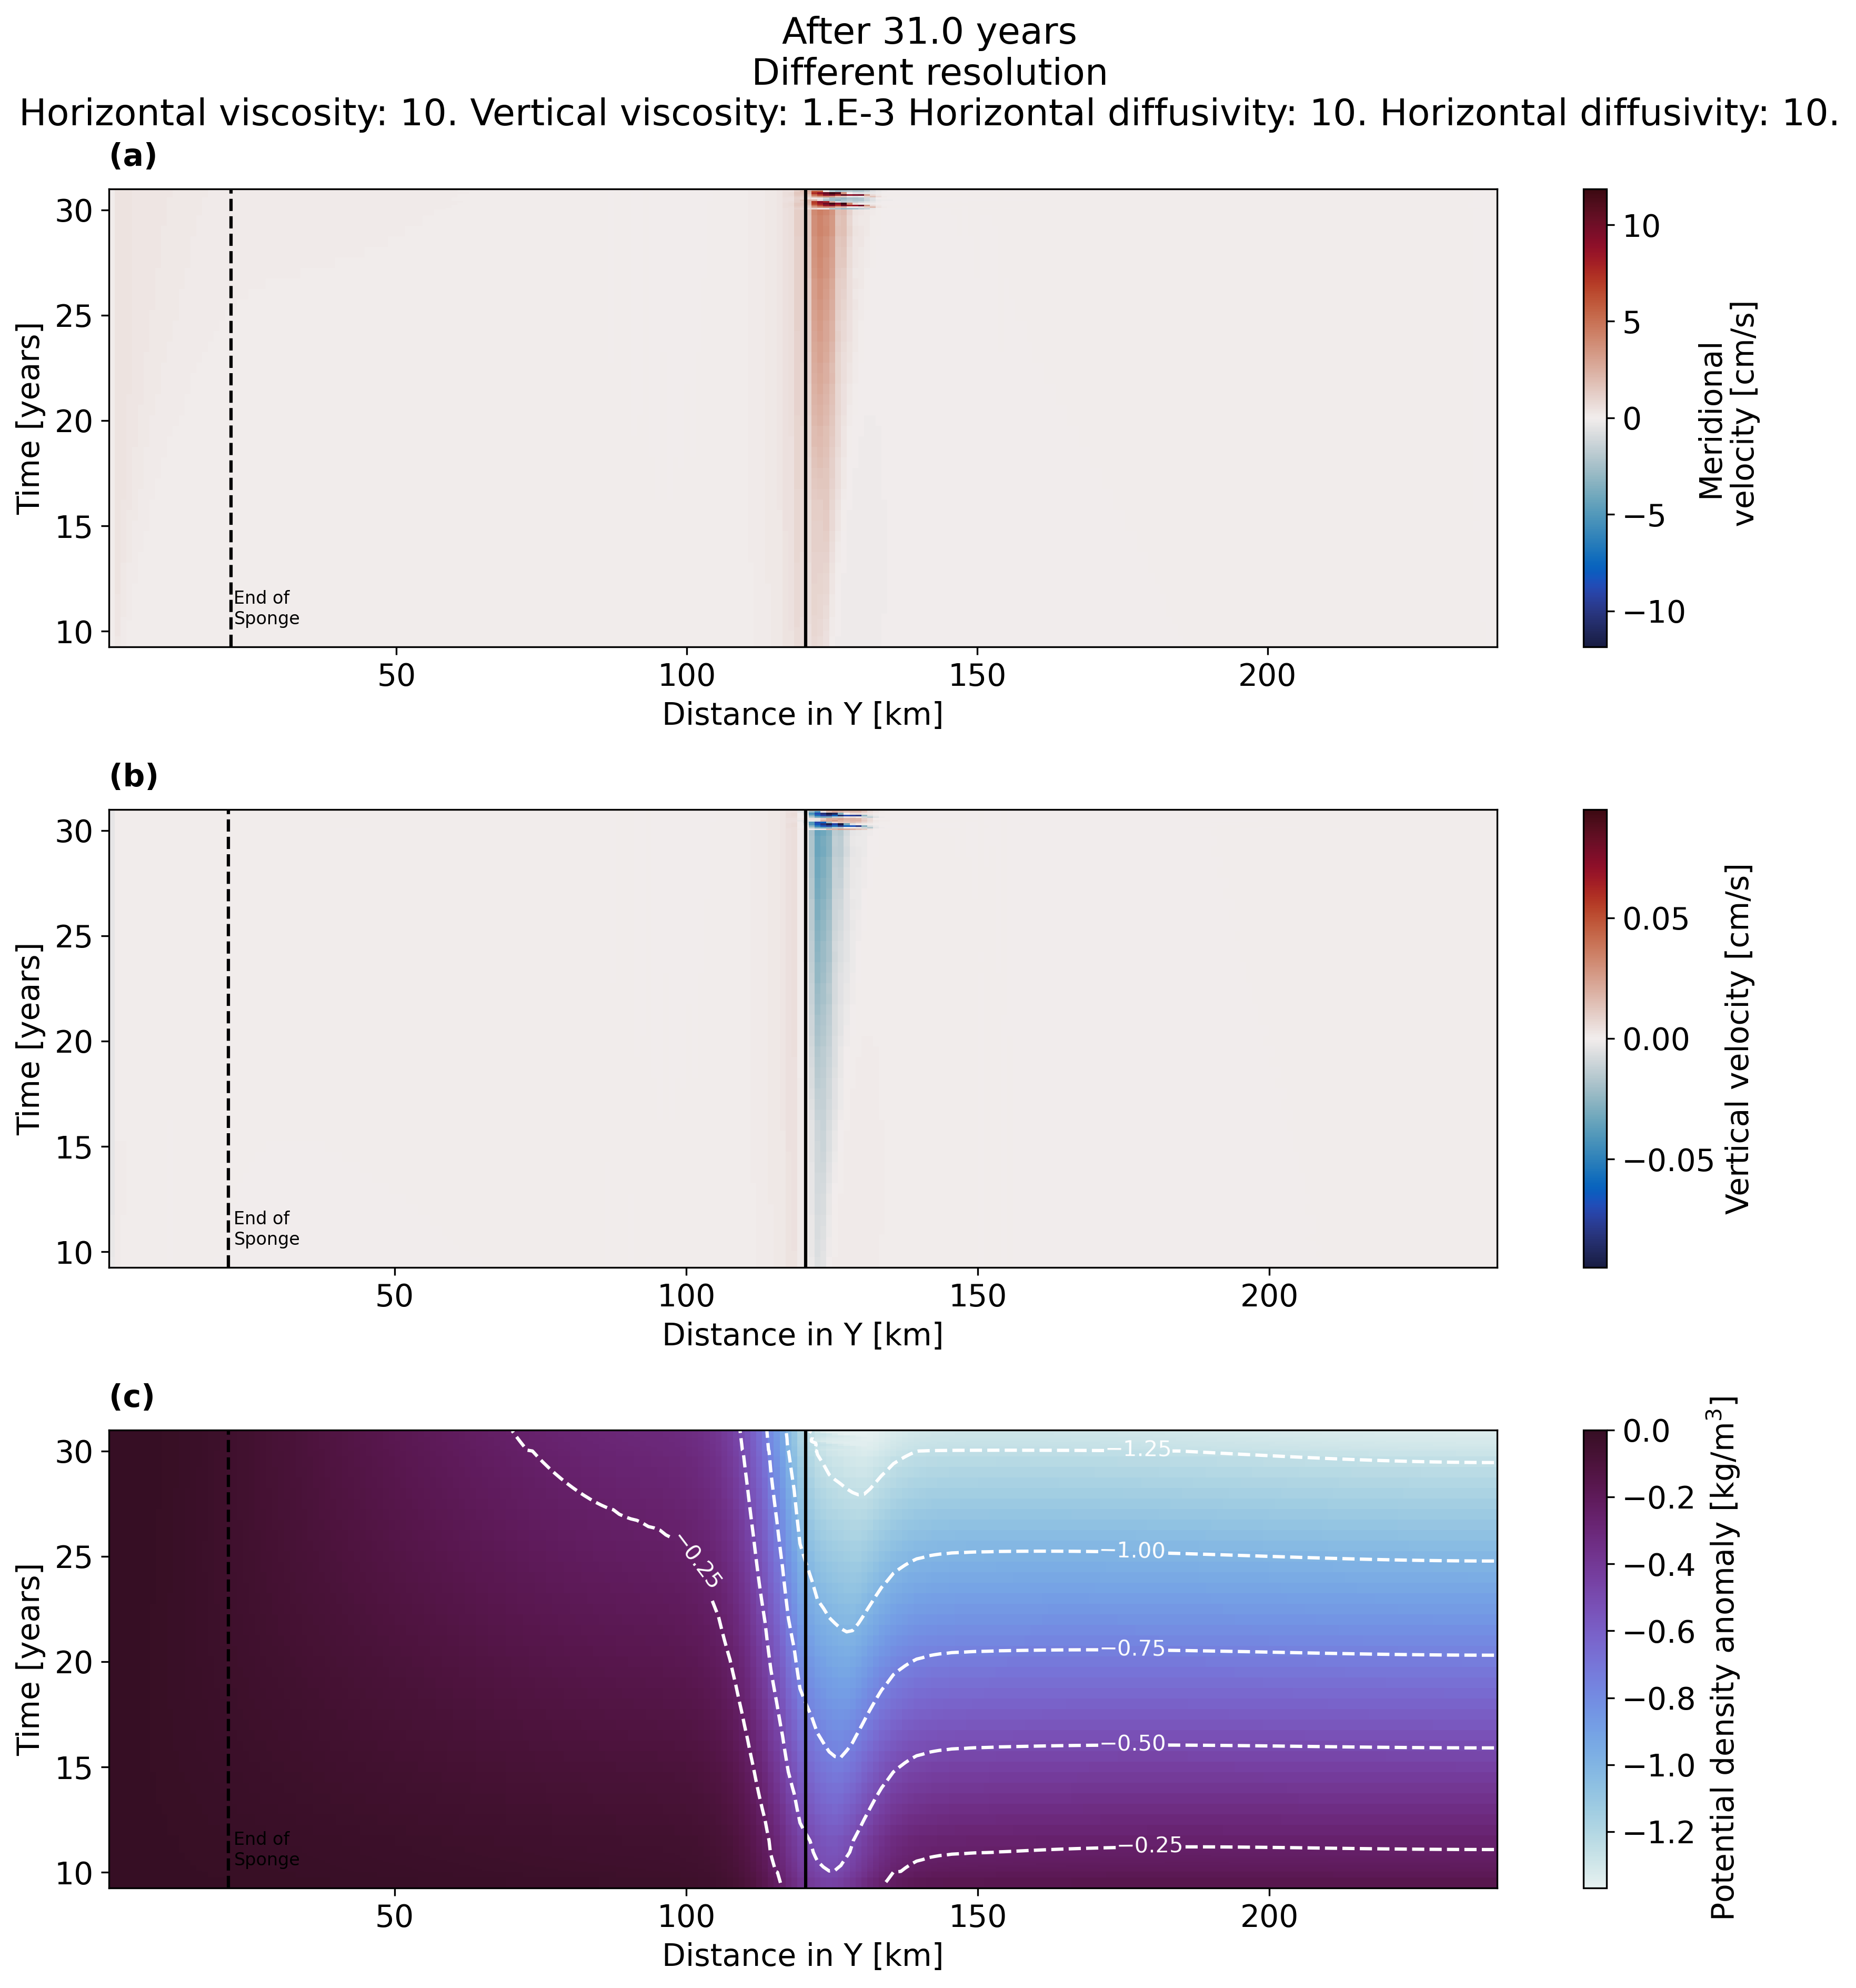

In [73]:
## Hovmöller ##

t=ds.T[tin:]/(60*60*24*360)

fig = plt.figure()
gs = GridSpec(nrows=3, ncols=1)

axin = fig.add_subplot(gs[0, 0])

Yin=ds.Yp1[OBp:OBendp]

vmin=-np.max(velout1[tinplot:,OB:OBend]*100)/divV
vmax=np.max(velout1[tinplot:,OB:OBend]*100)/divV
cmapi=cmocean.cm.balance

cax0=axin.pcolormesh(Yin/1000, t, velout1[tin:,OBp:OBendp]*100,vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax0)
axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')
cbar_ax.set_label('Meridional\n velocity [cm/s]')

axin.axvline(ds.Y[int(umbral)]/1000,c='k')
axin.text(0, 1.05, '(a)', fontweight='bold', color='k',
        transform=axin.transAxes)
axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

#axin.axhline(31,c='k',linestyle='dashed')
#axin.text(0.7, 0.35, 'Above output is averaged over 10 days\n\nBelow  output is instantaneous snapshot\nevery 10 days', color='k', 
#        transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[1, 0])


Yin=ds.Y[OBp:OBendp]

vmin=np.min(Wvelout1[tinplot:,OB:OBend]*100)/divW
vmax=-np.min(Wvelout1[tinplot:,OB:OBend]*100)/divW
cmapi=cmocean.cm.balance

axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')

cax0=axin.pcolormesh(Yin/1000,t, Wvelout1[tin:,OBp:OBendp]*100,vmin=vmin,vmax=vmax,cmap=cmapi)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Vertical velocity [cm/s]')

axin.axvline(ds.Y[int(umbral)]/1000,c='k')
axin.text(0, 1.05, '(b)', fontweight='bold', color='k',
        transform=axin.transAxes)

axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

#axin.axhline(31,c='k',linestyle='dashed')
#axin.text(0.7, 0.35, 'Above output is averaged over 10 days\n\nBelow  output is instantaneous snapshot\nevery 10 days', color='k', 
 #       transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[2, 0])


Yin=ds.Y[OBp:OBendp]

vmin=np.min(Rhoout1[tinplot:,OB:OBend])
vmax=np.max(Rhoout1[tinplot:,OB:OBend])
cmapi=cmocean.cm.dense

levels=np.linspace(vmin,vmax,15)

axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')

cax0=axin.pcolormesh(Yin/1000,t, Rhoout1[tin:,OBp:OBendp],vmin=vmin,vmax=vmax,cmap=cmapi)
contours=axin.contour(Yin/1000,t, Rhoout1[tin:,OBp:OBendp],levels=5,colors='white') #np.flip([-0.9,-0.925,-0.95,-1,-1.05])
plt.clabel(contours, inline=1, fontsize=10)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Potential density anomaly [kg/m$^3$]')


axin.text(0, 1.05, '(c)', fontweight='bold', color='k',
        transform=axin.transAxes)

axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)
axin.axvline(ds.Y[int(umbral)]/1000,c='k')
    
fig.tight_layout()
fig.suptitle(f'After {t[-1]:.1f} years\n Different resolution \n{plotNames[0]}: {plotValues[0]} {plotNames[1]}: {plotValues[1]} {plotNames[2]}: {plotValues[2]} {plotNames[2]}: {plotValues[2]}',y=1.05)


plt.savefig('../' + str(project)+'/Figures/' +str(ed)+ 'LastYearhovmöller' +'viscHor'+str(plotValues[0])+'viscVert'+str(plotValues[1])+'diffHor'+str(plotValues[2]) +'diffVert'+str(plotValues[3])+ '.png',dpi=400)



In [175]:
params = {'font.size': 10,
          'figure.figsize': (8, 4),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [136]:
tinmerid=0

In [137]:
def animateLine(t):
    tt=(t+1+tinmerid)*((ds.T.values[1]-ds.T.values[0])/(60*60*24*360))
    pax1.set_ydata(velout1[t+tinmerid,OB:OBend]*100)
    pax2.set_ydata(velout2[t+tinmerid,OB:OBend]*100)
    fig.suptitle(f'After {tt:.1f} years')


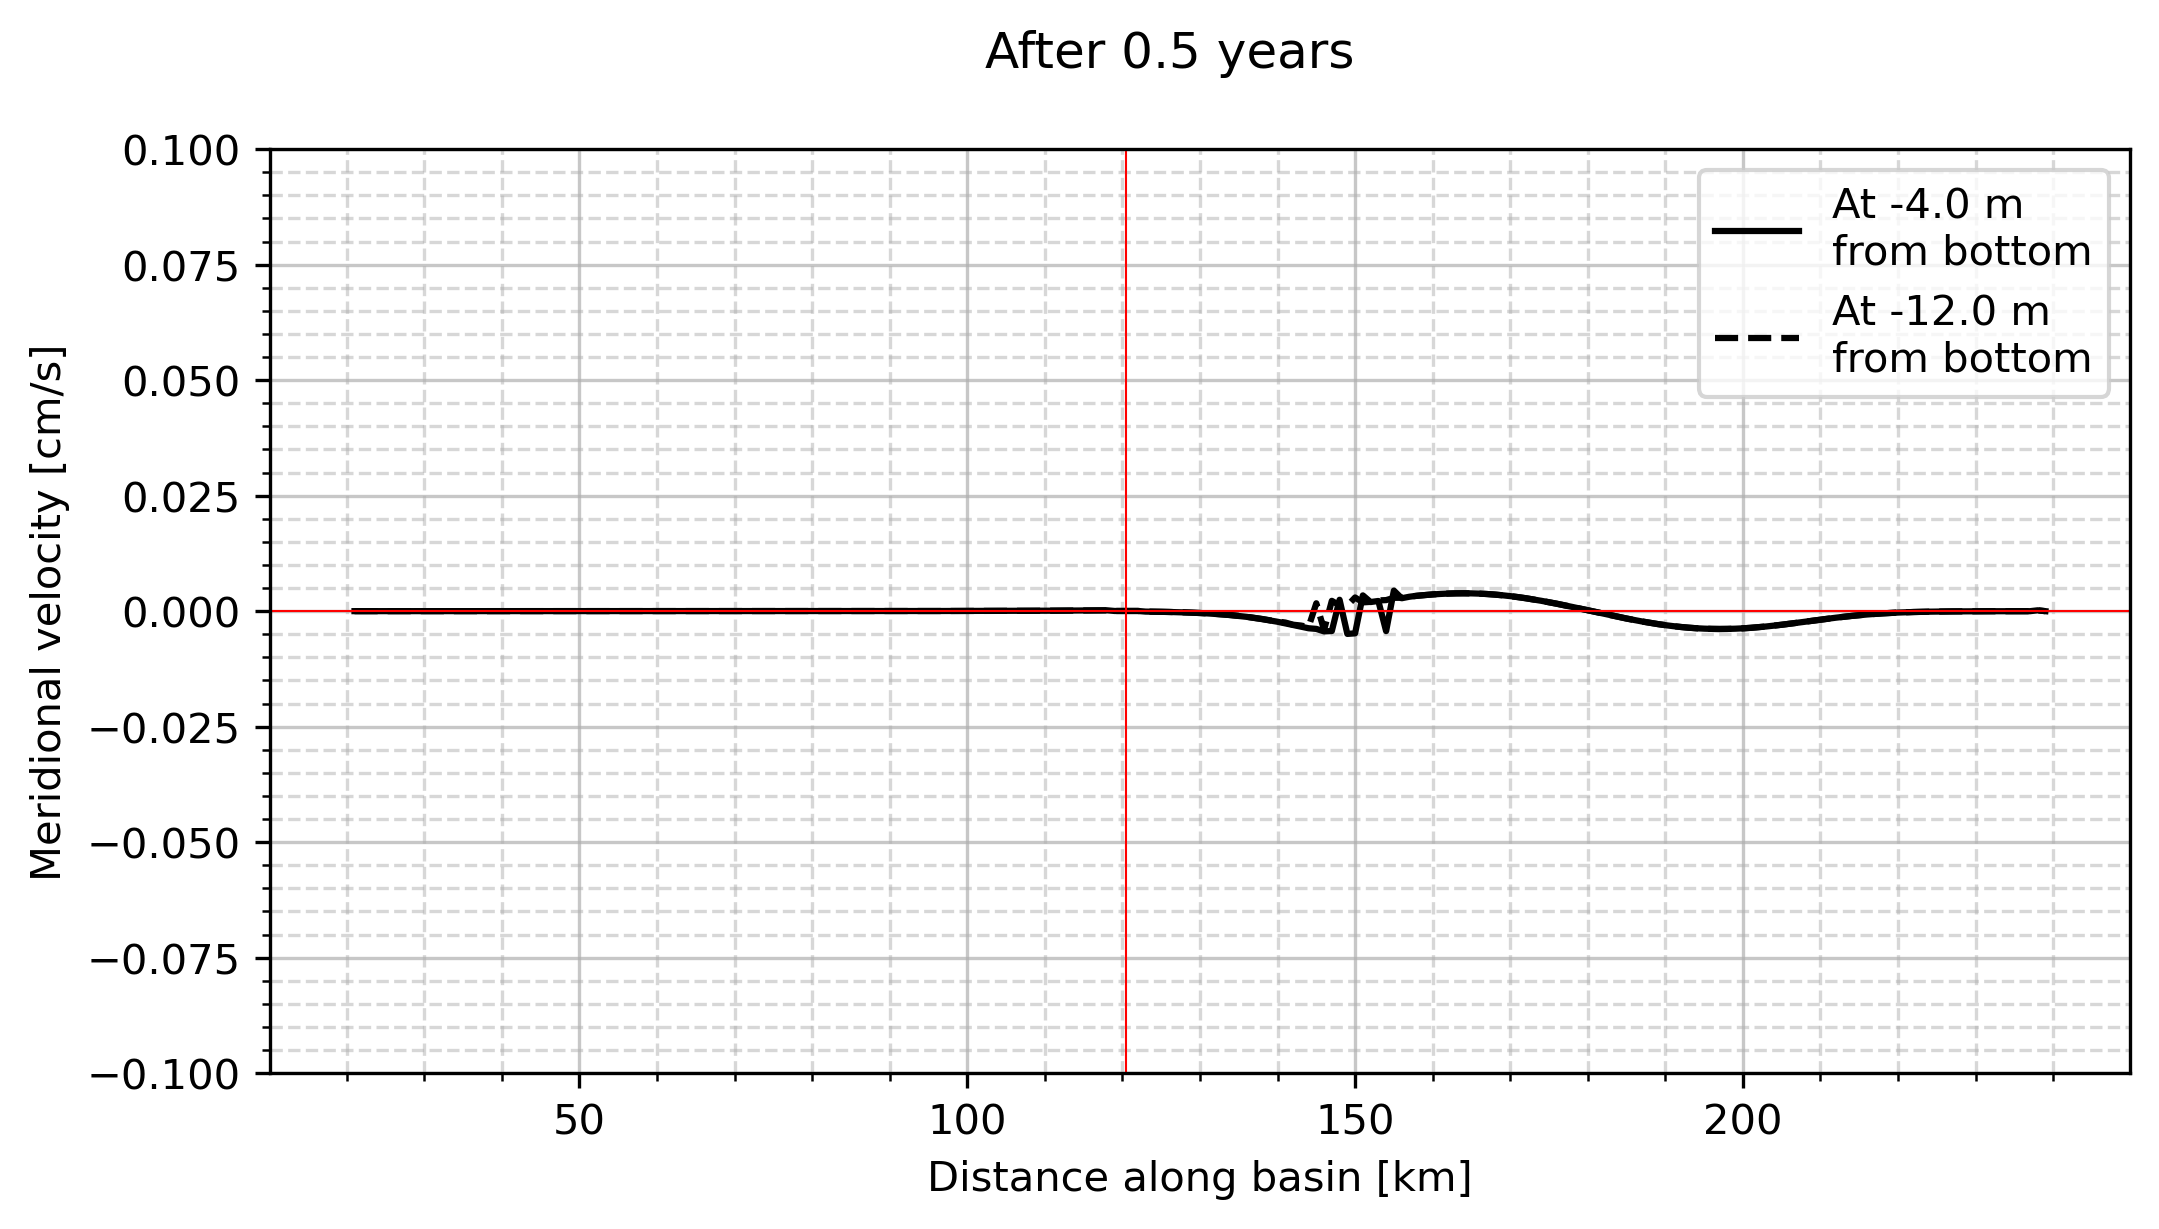

In [76]:
fig,ax=plt.subplots()
pax1,=ax.plot(ds.Yp1[OB:OBend]/1000,velout1[tinmerid,OB:OBend]*100,color='k', label=f'At {dsG.Z[0].values} m\nfrom bottom')
pax2,=ax.plot(ds.Yp1[OB:OBend]/1000,velout1[tinmerid,OB:OBend]*100,color='k',linestyle='dashed', label=f'At {dsG.Z[1].values} m\nfrom bottom')
ax.set(ylabel='Meridional velocity [cm/s]',xlabel='Distance along basin [km]')

tt=(1+tinmerid)*((ds.T.values[1]-ds.T.values[0])/(60*60*24))
fig.suptitle(f'After {tt:.1f} days')
    
ax.minorticks_on()

ax.grid(which='minor',linestyle='--', alpha=0.5)
ax.grid(which='major',alpha=0.7)
ax.legend()

ax.axvline(ds.Y[int(len(ds.Y)/2)]/1000,linewidth=0.5,color='red')
ax.axhline(0,linewidth=0.5,color='red')
ax.set_ylim((-0.1,0.1))
anim = FuncAnimation(fig, animateLine,frames=len(ds.T.values)-tinmerid, repeat=False)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'MeridVel1' +'viscHor'+str(plotNames[0])+'viscVert'+str(plotNames[1])+'diffHor'+str(plotNames[2]) +'diffVert'+str(plotNames[3])+ '.mp4', writer=writer, dpi=600)



In [77]:
def animateLineW(t):
    tt=(t+1+tinmerid)*((ds.T.values[1]-ds.T.values[0])/(60*60*24*360))
    pax1.set_ydata(Wvelout1[t+tinmerid,OB:OBend]*100)
    pax2.set_ydata(Wvelout2[t+tinmerid,OB:OBend]*100)
    fig.suptitle(f'After {tt:.1f} years')


In [78]:
np.min(Wvelout2[-1,OB:OBend]*100)

-0.0003363928726685117

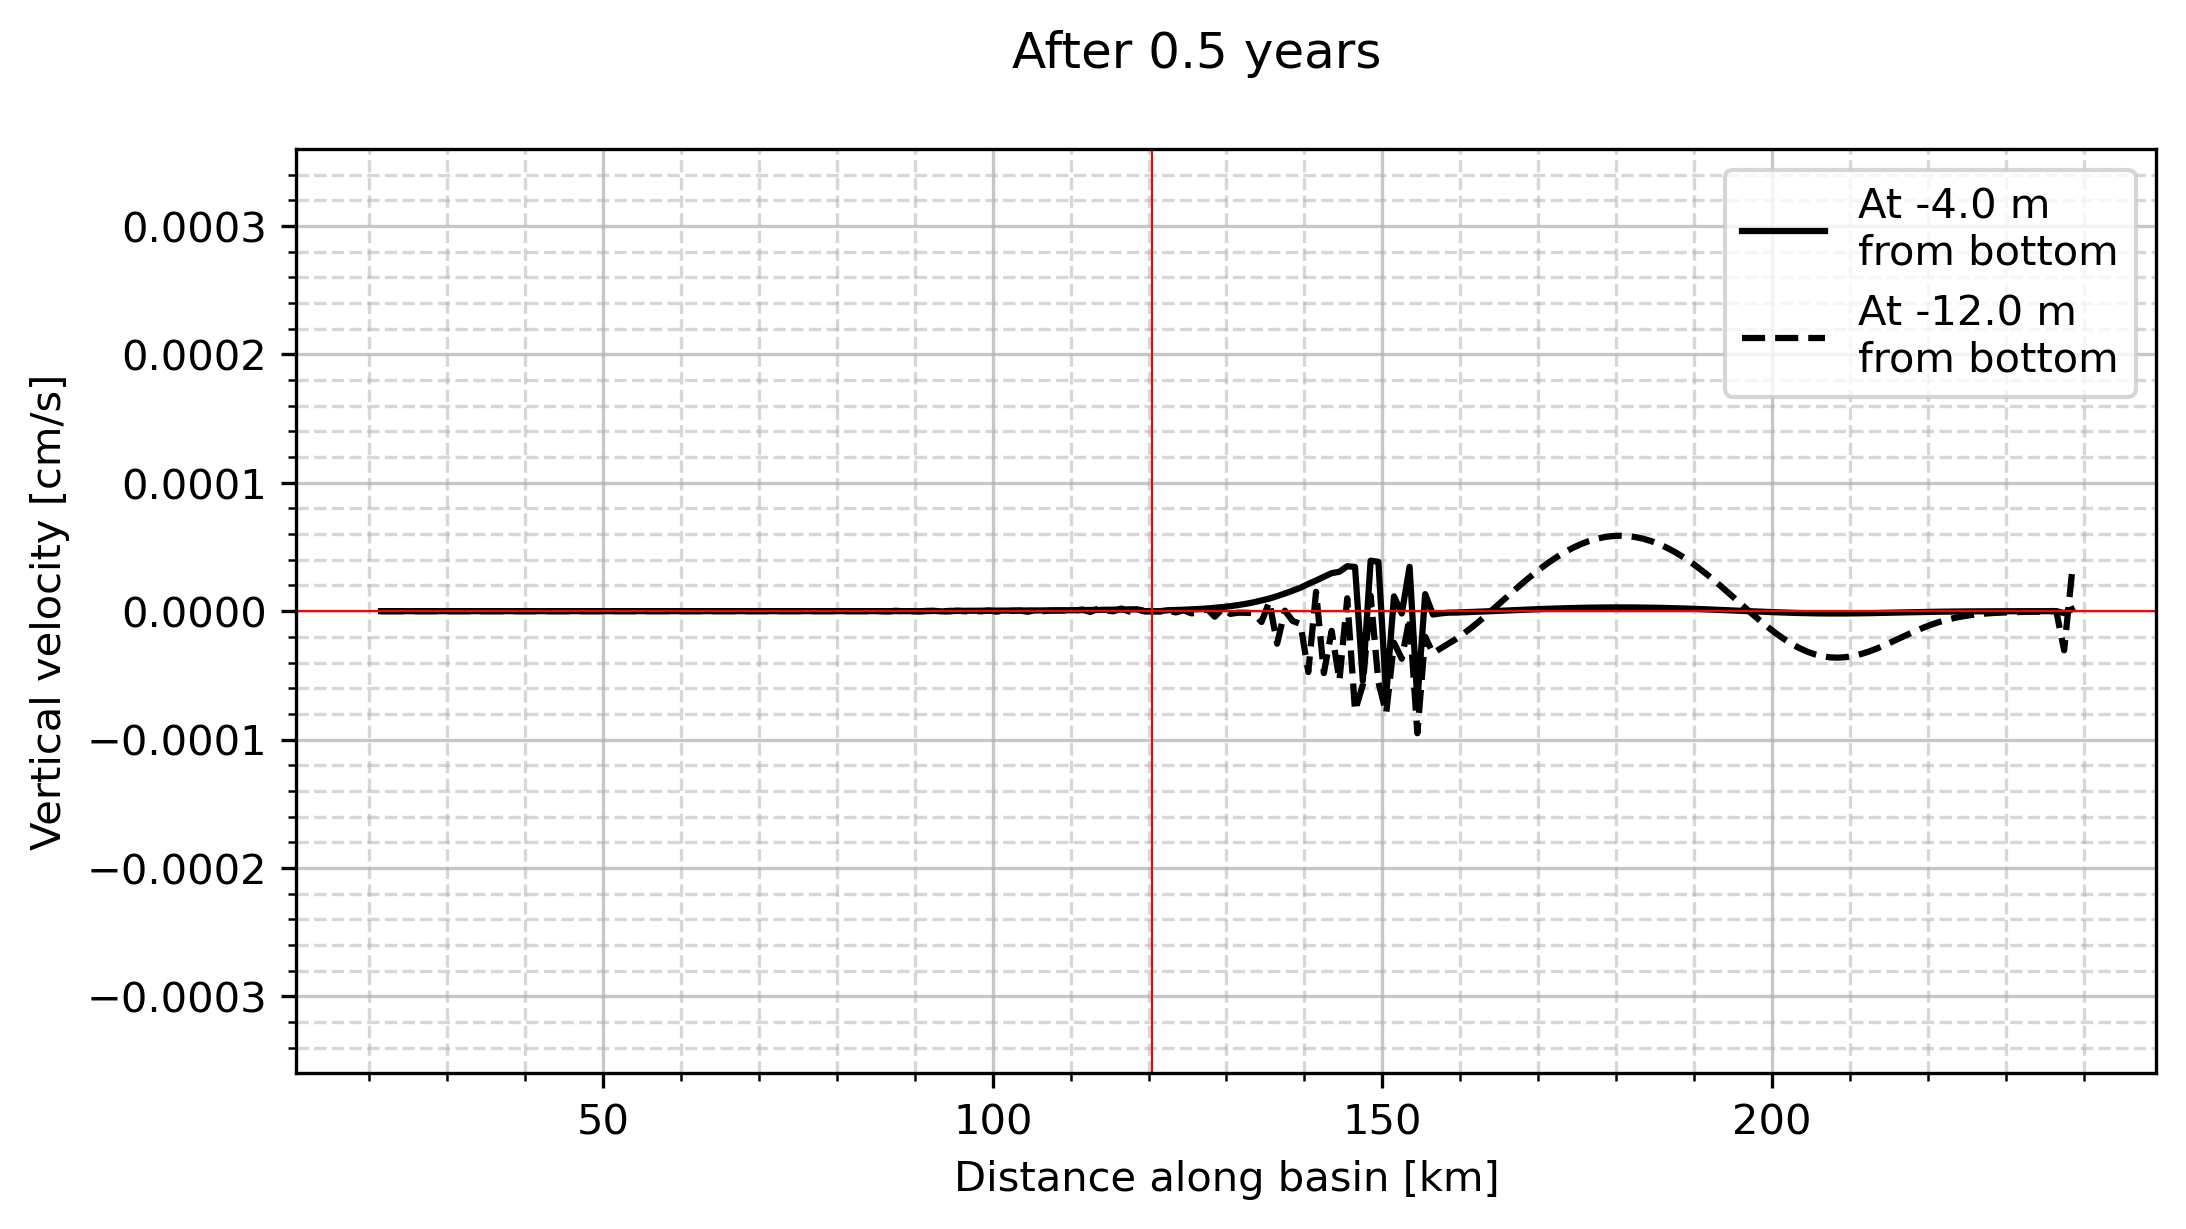

In [79]:
fig,ax=plt.subplots()
pax1,=ax.plot(ds.Y[OB:OBend]/1000,Wvelout1[tinmerid,OB:OBend]*100,color='k', label=f'At {dsG.Z[0].values} m\nfrom bottom')
pax2,=ax.plot(ds.Y[OB:OBend]/1000,Wvelout2[tinmerid,OB:OBend]*100,color='k',linestyle='dashed', label=f'At {dsG.Z[1].values} m\nfrom bottom')
ax.set(ylabel='Vertical velocity [cm/s]',xlabel='Distance along basin [km]')

tt=(1+tinmerid)*((ds.T.values[1]-ds.T.values[0])/(60*60*24))
fig.suptitle(f'After {tt:.1f} days')
    
ax.minorticks_on()

ax.grid(which='minor',linestyle='--', alpha=0.5)
ax.grid(which='major',alpha=0.7)

ax.axvline(ds.Y[int(len(ds.Y)/2)]/1000,linewidth=0.5,color='red')
ax.axhline(0,linewidth=0.5,color='red')
ax.legend()
ax.set_ylim((-np.max(Wvelout2[-1,OB:OBend]*100),np.max(Wvelout2[-1,OB:OBend]*100)))

anim = FuncAnimation(fig, animateLineW,frames=len(ds.T.values)-tinmerid, repeat=False)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'VerticalVel' +'viscHor'+str(plotNames[0])+'viscVert'+str(plotNames[1])+'diffHor'+str(plotNames[2]) +'diffVert'+str(plotNames[3])+ '.mp4', writer=writer, dpi=600)



# State

In [176]:
varst='state'

dsst=xr.open_dataset(str(location) +  str(varst) + '.nc')

In [177]:
def animateState(t):
    tt=((dsst.T.values[t])/(60*60*24))
    cax0.set_array(np.ma.masked_array(T[t,:,OBp:OBendp,0],mask=mask[:,OBp:OBendp,0]))
    cax1.set_array(np.ma.masked_array(V[t,:,OBp:OBendp,0]*100,mask=masks[:,OBp:OBendp,0]))
    cax2.set_array(np.ma.masked_array(np.mean(U[t,:,OBp:OBendp,:],axis=2)*100,mask=maskw[:,OBp:OBendp,0]))
    cax3.set_array(np.ma.masked_array(W[t,:,OBp:OBendp,0]*100,mask=mask[:,OBp:OBendp,0]))
    fig.suptitle(f'After {tt:.1f} day')



In [178]:
divV=100
divU=1
divW=100

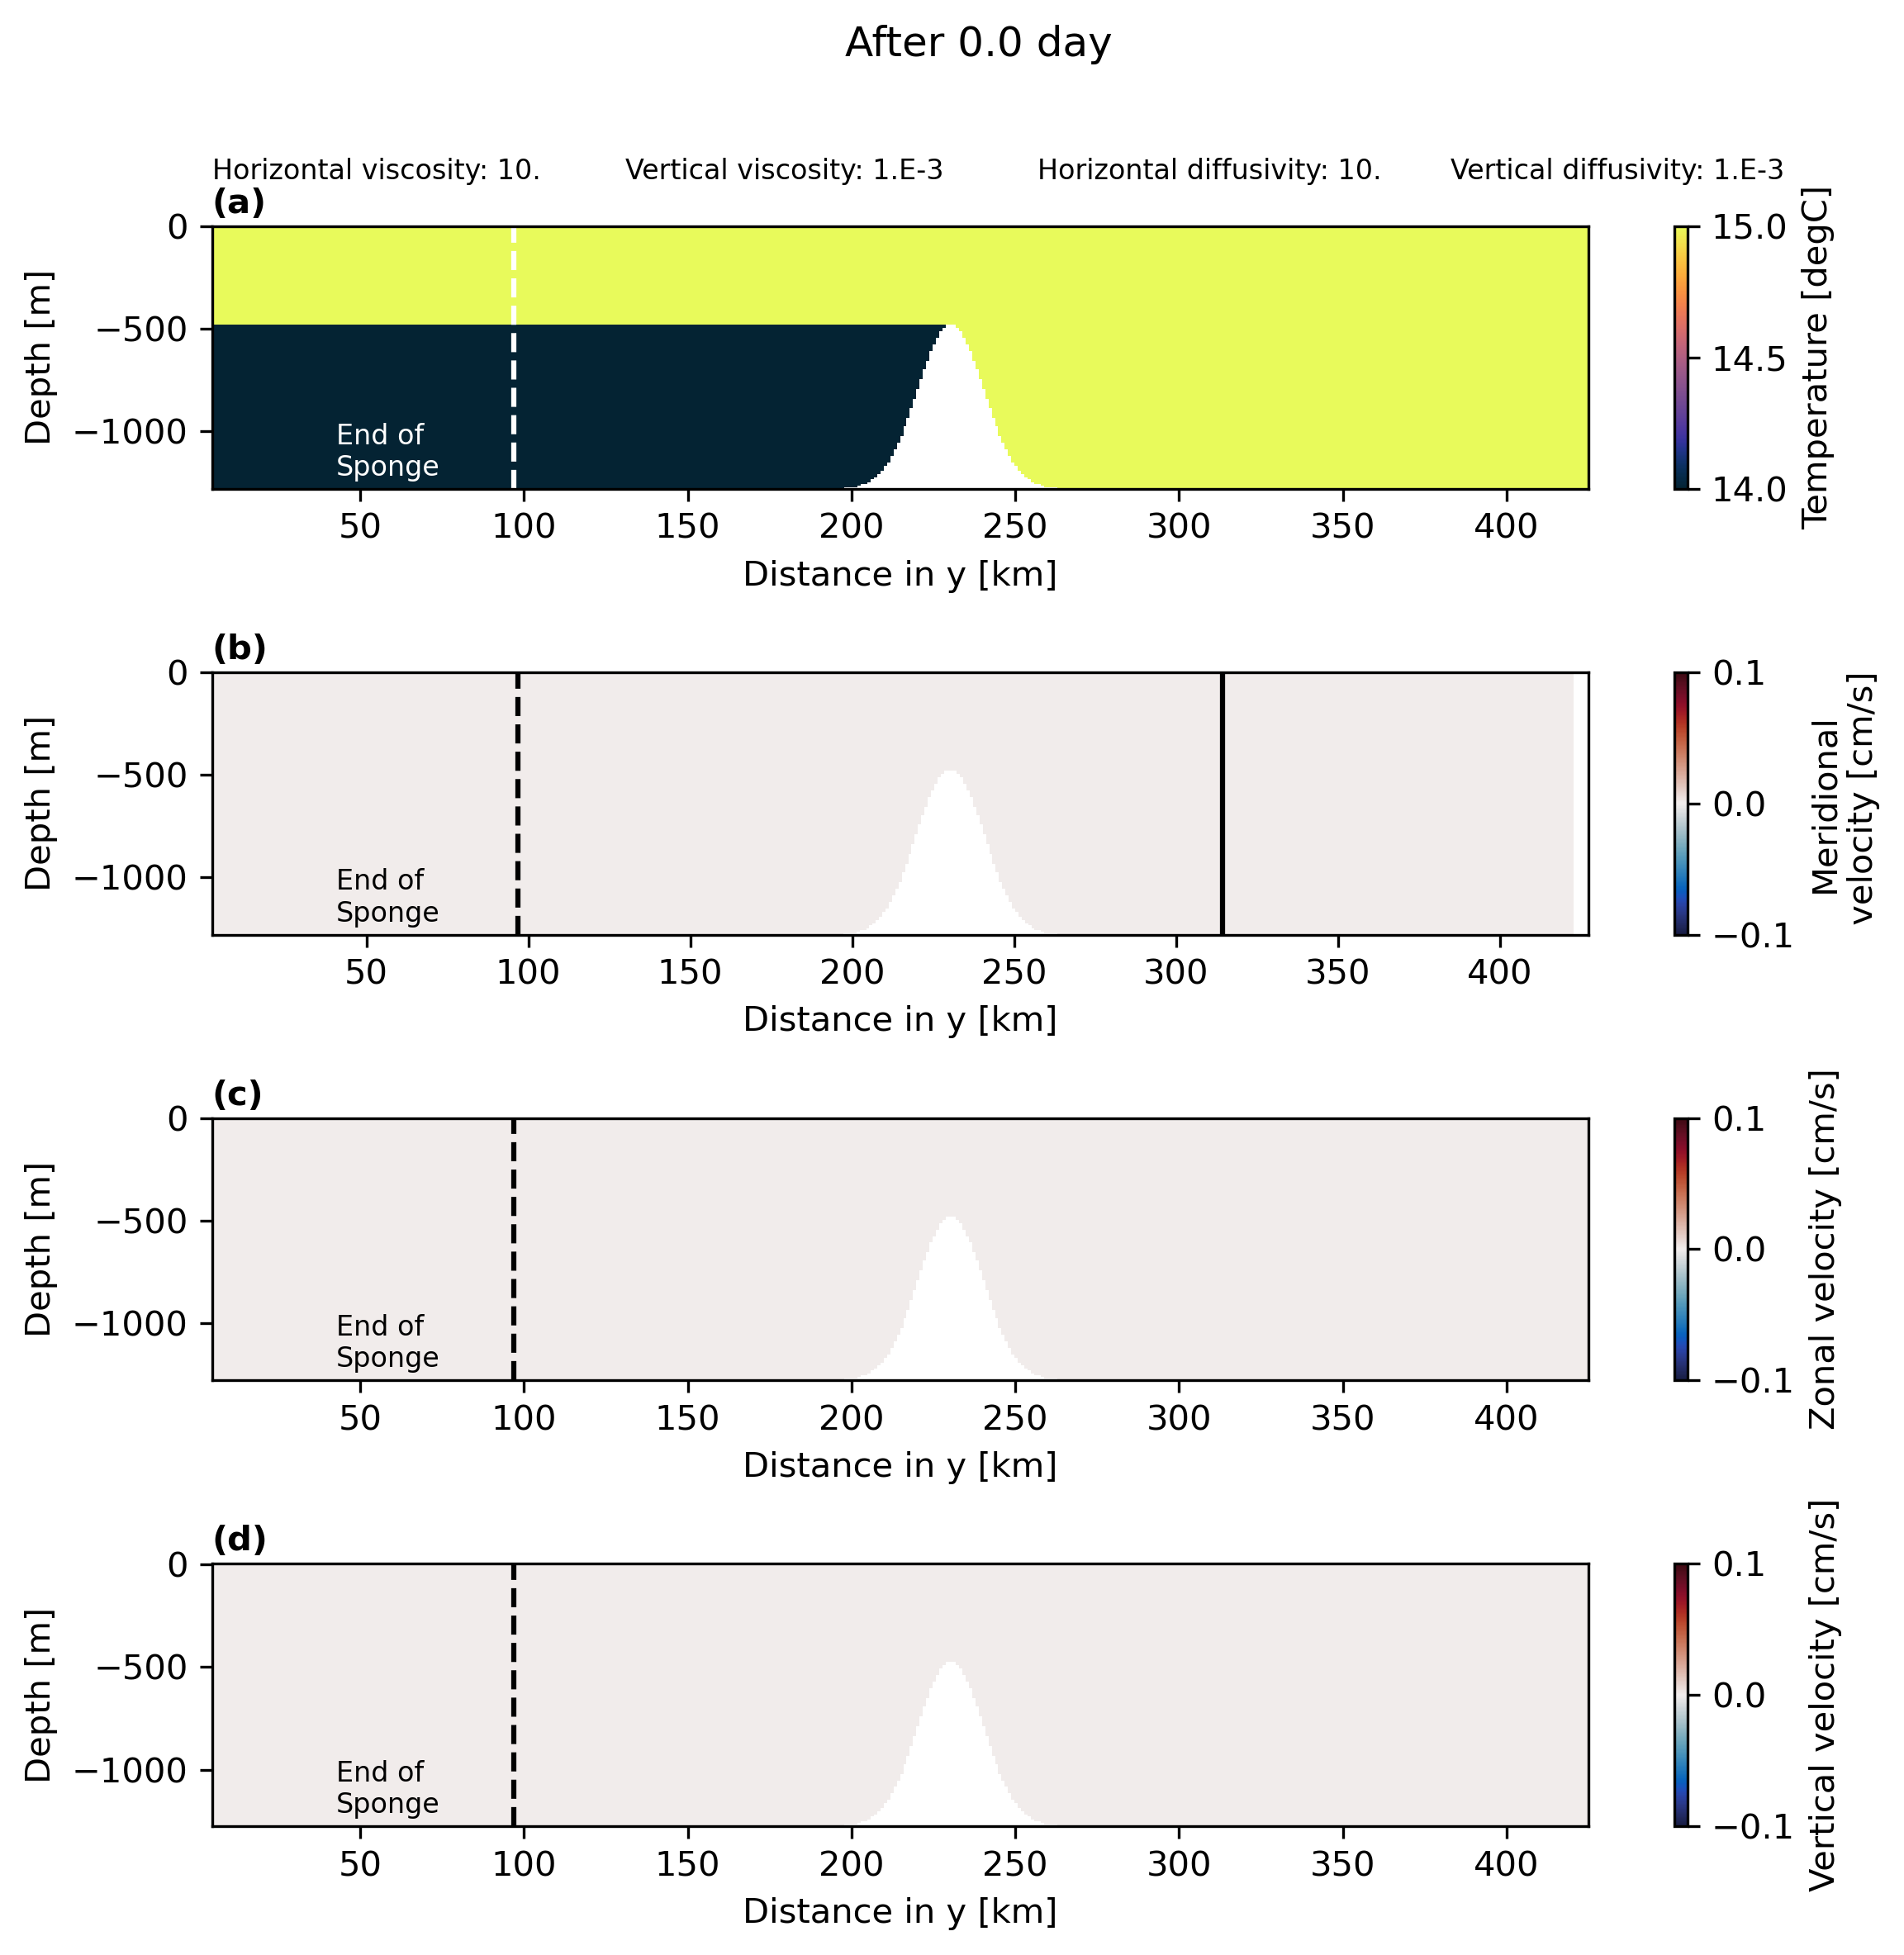

In [179]:
params = {'font.size': 10,
          'figure.figsize': (8, 8),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

fig = plt.figure()
gs = GridSpec(nrows=4, ncols=1)
axin = fig.add_subplot(gs[0, 0])
axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

T=dsst.Temp
Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Z

vmin=np.min(np.ma.masked_array(T[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))
vmax=np.max(np.ma.masked_array(T[tin,:,OB:OBend,0],mask=mask[:,OB:OBend,0]))
cmapi=cmocean.cm.thermal


timein=dsst.T[tin]/(60*60*24)
cax0=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp,0],mask=mask[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)
#caxC=axin.contour(Yin/1000, Zin, np.ma.masked_array(T[tin,:,OBp:OBendp,0]),levels=[15,15.02,15.08,15.2,15.5],colors='cyan')
#plt.clabel(caxC, inline=1, fontsize=8)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Temperature [degC]')

axin.text(0, 1.05, '(a)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[20]/1000,c='white',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=8)

s=1.18
for i in range(len(plotNames)):
    if i>3:
        s=1.15
        i=i-2
    axin.text(0+i*0.3, s, f'{plotNames[i]}: {plotValues[i]}', color='black', 
            transform=axin.transAxes,fontsize=8)

    
#axin.set_title(f'{plotNames[0]}:{plotValues[0]}, {plotNames[1]}:{plotValues[1]}\n {plotNames[2]}:{plotValues[2]}, {plotNames[3]}:{plotValues[3]}',fontsize=10)


axin = fig.add_subplot(gs[1, 0])

V=dsst.V.values

Yin=ds.Yp1[OBp:OBendp]

vmin=np.min(np.ma.masked_array(V[tin,:,OB:OBend,0]*100,mask=masks[:,OB:OBend,0]))/divV
vmax=-np.min(np.ma.masked_array(V[tin,:,OB:OBend,0]*100,mask=masks[:,OB:OBend,0]))/divV
cmapi=cmocean.cm.balance


axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')

cax1=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(V[tin,:,OBp:OBendp,0]*100,mask=masks[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax1)
axin.axvline(ds.Y[int(0.75*ny)]/1000,c='k')
cbar_ax.set_label('Meridional\n velocity [cm/s]')


axin.text(0, 1.05, '(b)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[2, 0])

U=dsst.U

Yin=ds.Y[OBp:OBendp]

vmin=np.min(np.ma.masked_array(np.mean(U[tin,:,OB:OBend,:],axis=2))*100)/divU
vmax=-np.min(np.ma.masked_array(np.mean(U[tin,:,OB:OBend,:],axis=2))*100)/divU
cmapi=cmocean.cm.balance



axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')


cax2=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(np.mean(U[tin,:,OBp:OBendp,:],axis=2)*100,mask=maskw[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax2)
cbar_ax.set_label('Zonal velocity [cm/s]')


axin.text(0, 1.05, '(c)', fontweight='bold', color='k', 
        transform=axin.transAxes)

axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)



W=dsst.W.values

Yin=dsG.Y[OBp:OBendp]
Zin=dsG.Zl

vmin=np.min(np.ma.masked_array(W[tin,:,OB:OBend,0]*100,mask=mask[:,OB:OBend,0]))/divW
vmax=-np.min(np.ma.masked_array(W[tin,:,OB:OBend,0]*100,mask=mask[:,OB:OBend,0]))/divW
cmapi=cmocean.cm.balance

axin = fig.add_subplot(gs[3, 0])

axin.set(xlabel='Distance in y [km]')
axin.set(ylabel='Depth [m]')


cax3=axin.pcolormesh(Yin/1000, Zin, np.ma.masked_array(W[tin,:,OBp:OBendp,0]*100,mask=mask[:,OBp:OBendp,0]),vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax3)
cbar_ax.set_label('Vertical velocity [cm/s]')

axin.axvline(ds.Y[20]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

axin.text(0, 1.05, '(d)', fontweight='bold', color='k', 
        transform=axin.transAxes)
tt=0
fig.suptitle(f'After {tt:.1f} years \n Different resolution')

fig.tight_layout()
anim = FuncAnimation(fig, animateState,frames=np.arange(0,len(dsst.T.values),1), repeat=False,interval=600)

anim.save('../' + str(project)+'/Figures/' +str(ed)+ 'StatedifRescrossects'  +'viscHor'+str(plotValues[0])+'viscVert'+str(plotValues[1])+'diffHor'+str(plotValues[2]) +'diffVert'+str(plotValues[3])+ '.mp4', writer=writer, dpi=600)


In [180]:
#Rho Linear EOS
alpha=2*1e-4
RHO=np.zeros(np.shape(dsst.Temp.values))
for i in range(len(ds.T)):
    RHO[i,:,:,:]=-999.8*np.ma.masked_array(dsst.Temp[i].values-15,mask=mask)*alpha

In [181]:
def BottomConc(vel, hfac, nz,nt, ny,loc):
    '''vel: Velocity field (nt,nz,ny)
       hfac: fraction of open cell at center (nz,ny)
       
       
       RETURNS:
       
       BotVel = velocity near bottom (nt,ny)'''
    
    BotVel = np.empty((nt,ny))
    BottomInd = np.argmax(hfac[::-1,:]>0.0,axis=0) # start looking for first no-land cell from the bottom up.
    BottomInd = (np.ones(np.shape(BottomInd))*nz - BottomInd)-loc # Get index of unreversed z axis
    
    for j in range(nt):
        for i in range(ny): 
            BotVel[j,i] = vel[j,int(BottomInd[i]),i] 
                
    
    return (BotVel,BottomInd)


In [184]:
velout1,BottomInd1=BottomConc(V[:,:,:,0],hFacS[:,:,0].values , nz, nt+3, ny+1,1)
velout2,BottomInd2=BottomConc(V[:,:,:,0],hFacS[:,:,0].values , nz, nt+3, ny+1,2)

Wvelout1,BottomInd=BottomConc(W[:,:,:,0],hFacC[:,:,0].values , nz, nt+3, ny,1)
Wvelout2,BottomInd=BottomConc(W[:,:,:,0],hFacC[:,:,0].values , nz, nt+3, ny,20)

Rhoout1,BottomInd=BottomConc(RHO[:,:,:,0],hFacC[:,:,0].values , nz, nt+3, ny,1)
Rhoout2,BottomInd=BottomConc(RHO[:,:,:,0],hFacC[:,:,0].values , nz, nt+3, ny,20)

In [183]:
params = {'font.size': 14,
          'figure.figsize': (12, 12),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [156]:
tin=np.where(dsst.T/(24*60*60*360)>0)[0][0]
tinplot=np.where(dsst.T/(24*60*60*360)>0)[0][0]

In [157]:
len(dsst.T)

142

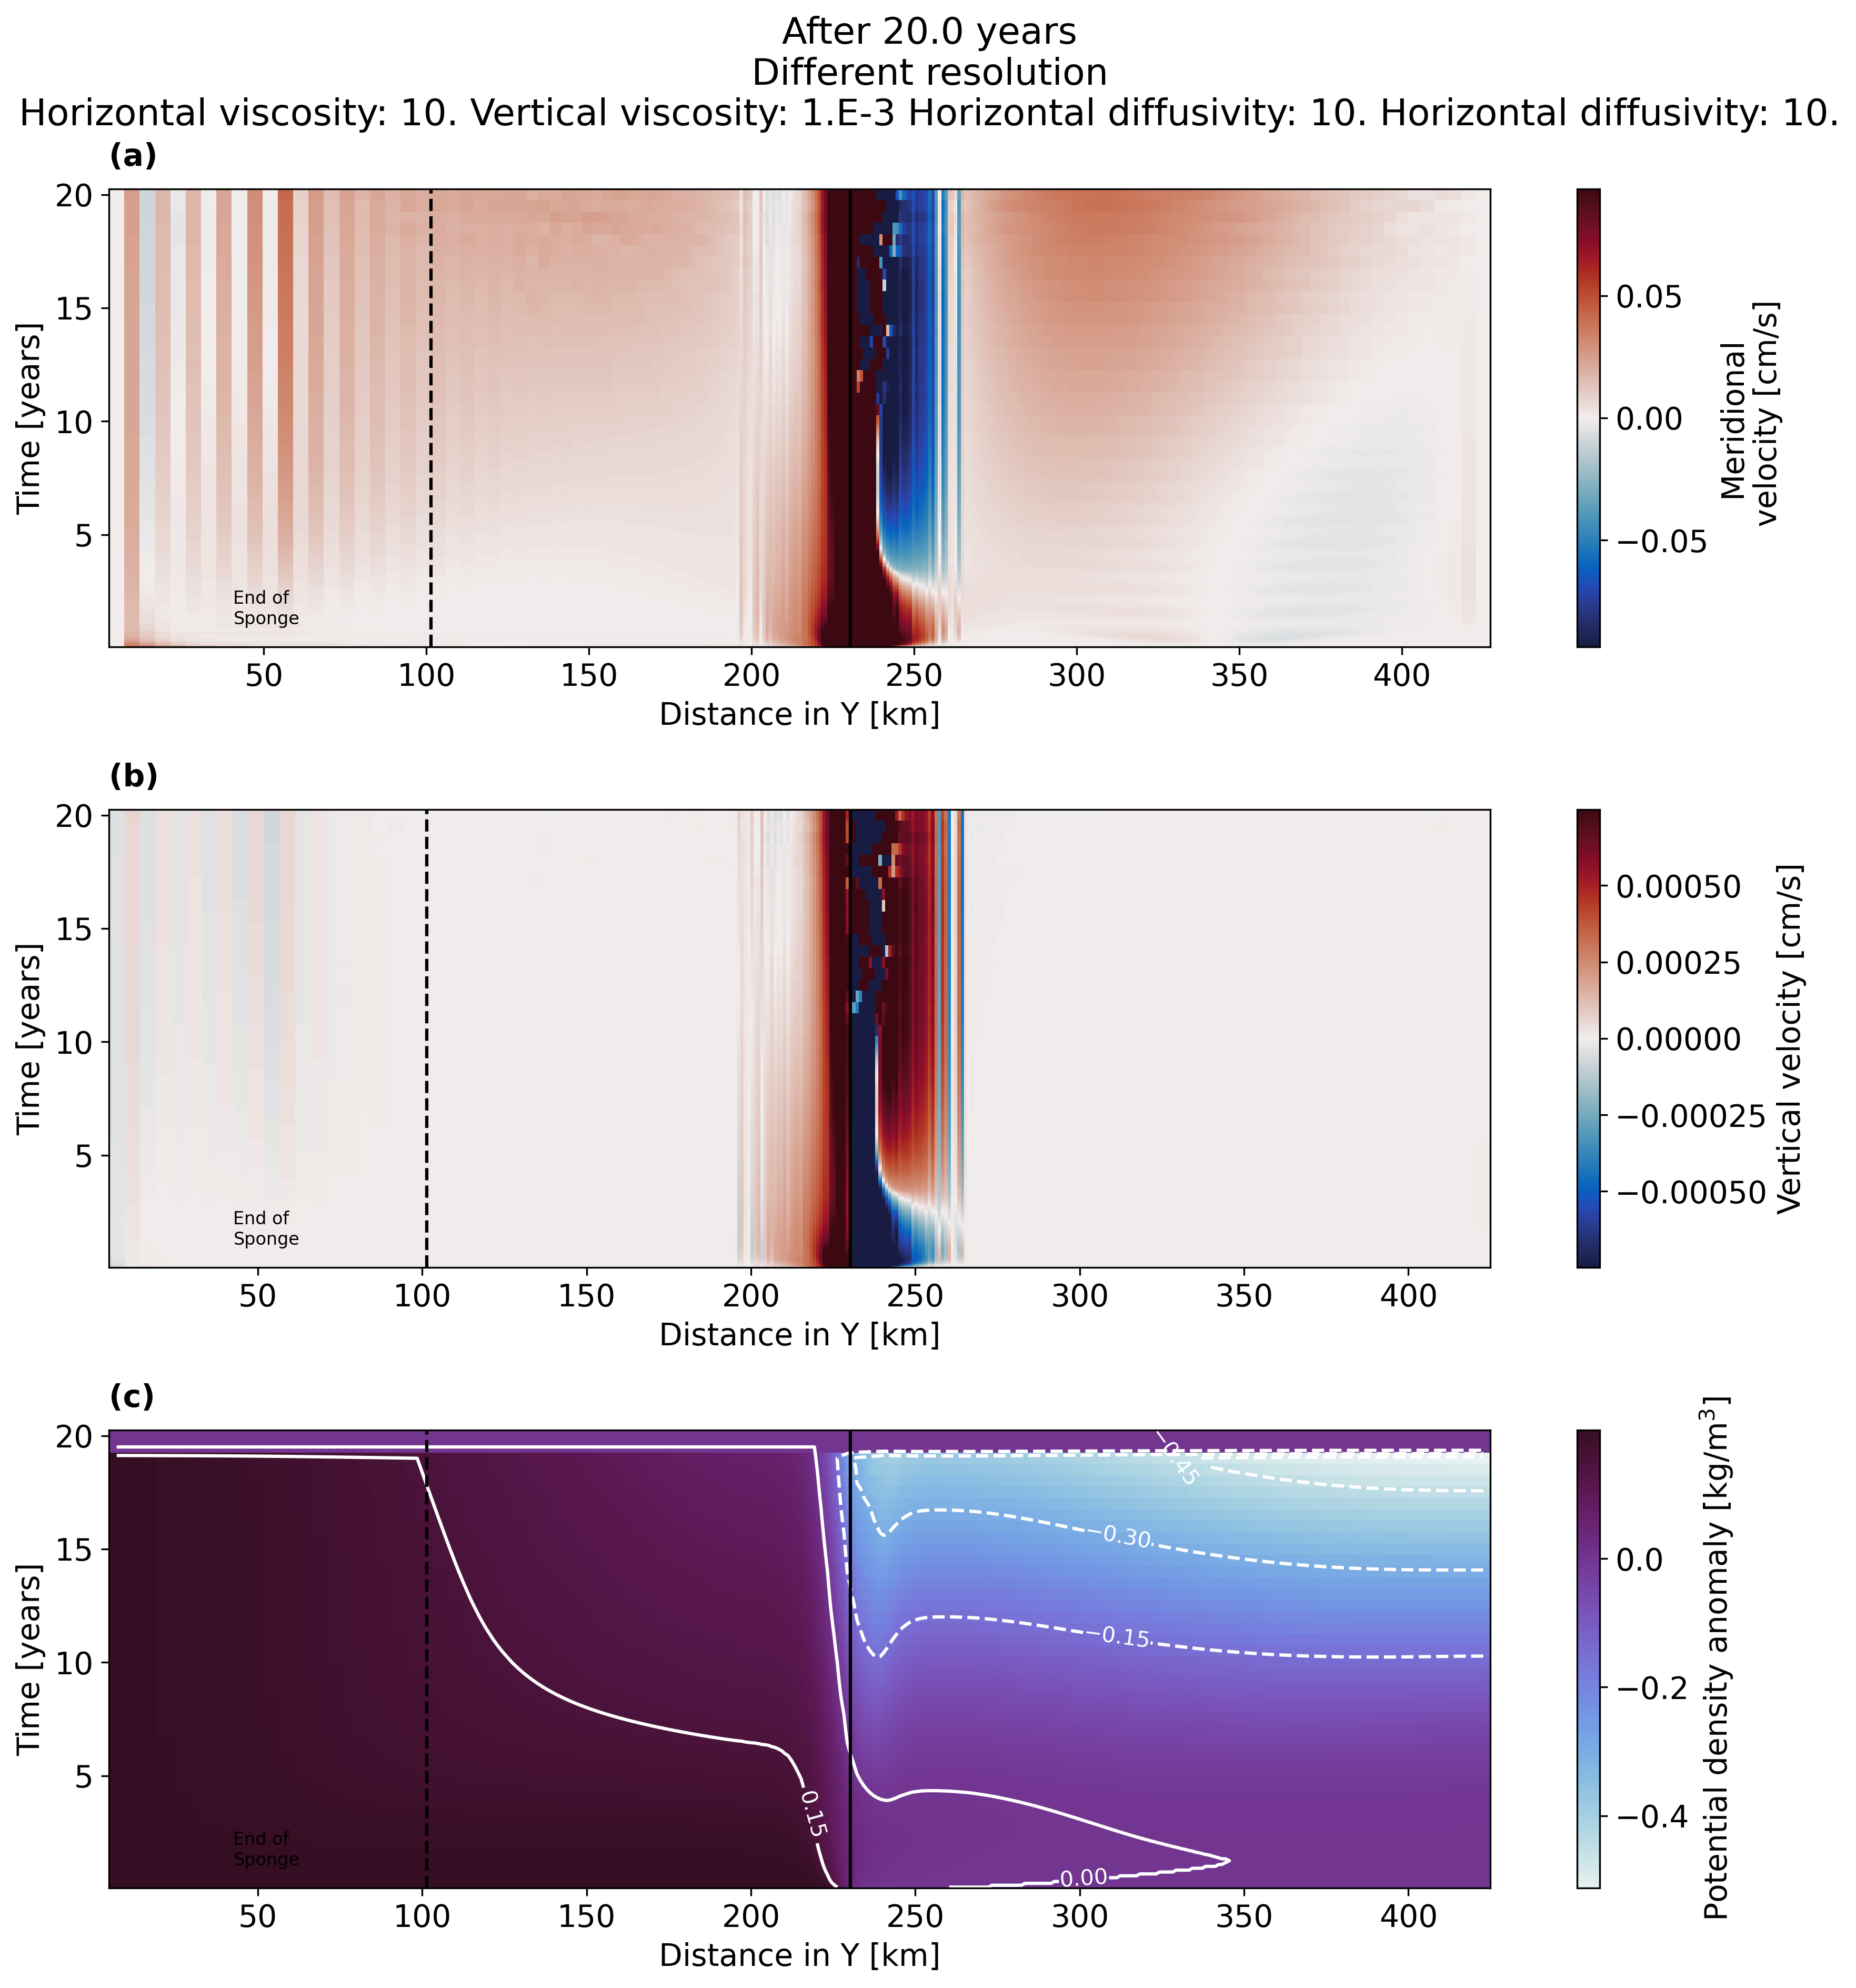

In [158]:
## Hovmöller ##

t=dsst.T[tin:]/(60*60*24*360)

fig = plt.figure()
gs = GridSpec(nrows=3, ncols=1)

axin = fig.add_subplot(gs[0, 0])

Yin=ds.Yp1[OBp:OBendp]

vmin=-np.max(velout1[tinplot:,OB:OBend]*100)/divV
vmax=np.max(velout1[tinplot:,OB:OBend]*100)/divV
cmapi=cmocean.cm.balance

levels=np.linspace(vmin,vmax,15)


cax0=axin.pcolormesh(Yin/1000, t, velout1[tin:,OBp:OBendp]*100,vmin=vmin,vmax=vmax,cmap=cmapi)

cbar_ax = plt.colorbar(cax0)
axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')
cbar_ax.set_label('Meridional\n velocity [cm/s]')

axin.axvline(ds.Y[int(umbral)]/1000,c='k')
axin.text(0, 1.05, '(a)', fontweight='bold', color='k',
        transform=axin.transAxes)
axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

#axin.axhline(31,c='k',linestyle='dashed')
#axin.text(0.7, 0.35, 'Above output is averaged over 10 days\n\nBelow  output is instantaneous snapshot\nevery 10 days', color='k', 
#        transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[1, 0])


Yin=ds.Y[OBp:OBendp]

vmin=np.min(Wvelout1[tinplot:,OB:OBend]*100)/divW
vmax=-np.min(Wvelout1[tinplot:,OB:OBend]*100)/divW
cmapi=cmocean.cm.balance

levels=np.linspace(vmin,vmax,15)

axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')

cax0=axin.pcolormesh(Yin/1000,t, Wvelout1[tin:,OBp:OBendp]*100,vmin=vmin,vmax=vmax,cmap=cmapi)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Vertical velocity [cm/s]')

axin.axvline(ds.Y[int(umbral)]/1000,c='k')
axin.text(0, 1.05, '(b)', fontweight='bold', color='k',
        transform=axin.transAxes)

axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)

#axin.axhline(31,c='k',linestyle='dashed')
#axin.text(0.7, 0.35, 'Above output is averaged over 10 days\n\nBelow  output is instantaneous snapshot\nevery 10 days', color='k', 
 #       transform=axin.transAxes,fontsize=8)

axin = fig.add_subplot(gs[2, 0])


Yin=ds.Y[OBp:OBendp]

vmin=np.min(Rhoout1[tinplot:,OB:OBend])
vmax=np.max(Rhoout1[tinplot:,OB:OBend])
cmapi=cmocean.cm.dense

levels=np.linspace(vmin,vmax,15)

axin.set(ylabel='Time [years]',xlabel='Distance in Y [km]')

cax0=axin.pcolormesh(Yin/1000,t, Rhoout1[tin:,OBp:OBendp],vmin=vmin,vmax=vmax,cmap=cmapi)
contours=axin.contour(Yin/1000,t, Rhoout1[tin:,OBp:OBendp],levels=5,colors='white') #np.flip([-0.9,-0.925,-0.95,-1,-1.05])
plt.clabel(contours, inline=1, fontsize=10)
cbar_ax = plt.colorbar(cax0)
cbar_ax.set_label('Potential density anomaly [kg/m$^3$]')


axin.text(0, 1.05, '(c)', fontweight='bold', color='k',
        transform=axin.transAxes)

axin.axvline(ds.Y[OB]/1000,c='k',linestyle='dashed')
axin.text(0.09, 0.05, 'End of \nSponge', color='k', 
        transform=axin.transAxes,fontsize=8)
axin.axvline(ds.Y[int(umbral)]/1000,c='k')
    
fig.tight_layout()
fig.suptitle(f'After {t[-1]:.1f} years\n Different resolution \n{plotNames[0]}: {plotValues[0]} {plotNames[1]}: {plotValues[1]} {plotNames[2]}: {plotValues[2]} {plotNames[2]}: {plotValues[2]}',y=1.05)


plt.savefig('../' + str(project)+'/Figures/' +str(ed)+ 'StatedifReshovmöller' +'viscHor'+str(plotValues[0])+'viscVert'+str(plotValues[1])+'diffHor'+str(plotValues[2]) +'diffVert'+str(plotValues[3])+ '.png',dpi=400)

